# Convergence tests

Convergence diagnostics for the Gibbs chains produced by
`hydra-pspec-systematic`, split out of the `paper_plots_c_v2*` notebooks into a
self-contained notebook.

This notebook handles **one or more cases**.  With a single case it is an
independent assessment of that run; with several it is also a comparison, and
the cases are ranked against each other.  A "case" is one run directory, with
its own systematic modes, its own true systematic amplitudes and its own number
of foreground modes, so the three source notebooks are all covered by the same
`cases` list:

| Source notebook | `cases` entry |
|---|---|
| `paper_plots_c_v2.ipynb` | four runs, different `nm_list` / `dl_inds` per case |
| `paper_plots_c_v2_nfgmodes.ipynb` | several runs, shared `nm_list`, different `Nfgmodes` |
| `paper_plots_c_v2_single_case.ipynb` | one run |

Nothing here needs the expensive delay/fringe-rate sample loop of the paper
notebooks: only the small chains (`ln-post.npy`, `b-sys.npy`, `dps-eor.npy` and
one LST slice of `fg-amps.npy`) are read, so the notebook runs in a couple of
minutes.

## The diagnostics

The sampler produces a *single* chain per run, so the statistics used are the
ones that work on one chain:

* **Integrated autocorrelation time** $\tau_\mathrm{int}$ and **effective
  sample size** $N_\mathrm{eff} = N/\tau_\mathrm{int}$ (Sokal automatic
  windowing, via `emcee.autocorr`).  $\tau_\mathrm{int}$ is how many Gibbs
  iterations it takes the chain to forget where it was; $N_\mathrm{eff}$ is how
  many independent draws the chain is worth.  Because the cases need not have
  run for the same number of iterations, the comparison below uses the
  **efficiency** $N_\mathrm{eff}/N$.
* **Rank-normalised split-$\hat{R}$** (Vehtari et al. 2021).  The chain is cut
  into `CONV_NSPLIT` consecutive segments which are then compared as if they
  were independent chains, so a chain that is still drifting, or that is stuck
  in different regions at different times, gives $\hat{R} > 1$.  The
  conventional threshold is $\hat{R} \lesssim 1.01$.
* **Geweke $z$**.  Compares the mean of the first 10 % of the chain with the
  mean of the last 50 %, in units of the autocorrelation-corrected standard
  error of the two windows.  For a stationary chain $z \sim \mathcal{N}(0,1)$,
  so $|z| > 2$ means burn-in is not complete.
* **Monte Carlo standard error** $\mathrm{MCSE} = \sigma/\sqrt{N_\mathrm{eff}}$
  — the sampling noise left on a posterior mean.

Monitored parameter blocks: the joint log-posterior $\ln\mathcal{L}$, the
systematic amplitudes $b_\mathrm{sys}$, the EoR delay power spectrum in the
delay bins occupied by the systematics, and the foreground amplitudes
$a_\mathrm{fg}$ at LST index `fg_amp_time_idx`.  Every case is scored by its
*worst* monitored scalar: a sampler has only converged if all of its parameters
have.

**Caveats.**  These statistics can only ever *detect* non-convergence, never
prove convergence.  With one chain per run they are blind to a mode the sampler
never visited, and blocked Gibbs updates correlate all of the parameter blocks,
so the numbers below are more useful for *ranking* the cases against each other
than as absolute statements about any single run.

## Imports

In [55]:
import os
import time

_notebook_start = time.time()

import numpy as np
import emcee

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

from astropy import units as u

from scipy.stats import norm as _norm, rankdata as _rankdata

from plotting_codes import tables as tbl   # presentable diagnostic tables

## Configuration

Everything that changes between analyses lives in this cell.

Each entry of `cases` is one run directory under `result_dir`:

| key | required | meaning |
|---|---|---|
| `run` | yes | sub-folder of `result_dir` |
| `label` | no | legend / table label (LaTeX allowed); defaults to `run` |
| `nm_list` | no | systematic modes `(n, m)` of the run |
| `dl_inds` | no | delay indices of the systematics; defaults to `[n for (n, m) in nm_list]` |
| `sys_amps_true` | no | true systematic amplitudes; needed only for the accuracy table |
| `Nfgmodes` | no | foreground modes to monitor; `None` reads it from `fgmodes.npy` |

`dl_inds` is kept separate from `nm_list` because the paper notebooks do not
always set it to `n` (Case III of `paper_plots_c_v2.ipynb` uses `[3, 3, 3, 3]`
for modes `(3, 20) … (6, 20)`).  Give it explicitly whenever the run does.

In [56]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/250k_run/'  # run outputs
parent_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/'                       # repo root
fig_dir     = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/convergence'
table_dir   = None    # Markdown/LaTeX/CSV/HTML copies of every table (None = fig_dir/tables)
fig_suffix  = '_conv' # appended to every PDF name, so nothing clashes with the paper figures

SAVE_FIGS   = False    # write PDFs to fig_dir
SAVE_TABLES = False    # write .md / .tex / .csv / .html copies of every table to table_dir
USE_MMAP    = True    # memory-map fg-amps.npy (only one LST slice is ever read)

# ── Cases ─────────────────────────────────────────────────────────────────────
# One or more.  With one case this notebook is an independent assessment of that
# run; with several it also ranks them against each other.
# Truncated Case I  : nm_list = [(3,0),  (4,0)]
# Truncated Case II : nm_list = [(5,0), (6,0)]
# Truncated Case III: nm_list = [(3,8), (4,8)]
cases = [
    # dict(run='low_dl_fr_0',
    #      label=r'Case I',
    #      nm_list=[(3, 0), (4, 0), (5, 0), (6, 0)],
    #     #   nm_list=[(3,0),  (4,0)],
    #     #  dl_inds=[3, 4],
    #      sys_amps_true=[1. + 4j, 2. + 3j, 3. + 2j, 4. + 1j],
    #     #   sys_amps_true = [12. + 5j, 4. + 20j],
    #      Nfgmodes=None),
    # dict(run='high_dl_fr_0',
    #      label=r'Case II',
    #      nm_list=[(10, 0), (11, 0), (12, 0), (13, 0)],
    #     # nm_list = [(5,0), (6,0)],
    #      dl_inds=[10, 11, 12, 13],
    #     # dl_inds = [5, 6],
    #      sys_amps_true=[1. + 4j, 2. + 3j, 3. + 2j, 4. + 1j],
    #      Nfgmodes=None),
    # dict(run='low_dl_fr_20',
    #      label=r'Case III',
    #      nm_list=[(3, 20), (4, 20), (5, 20), (6, 20)],
    #     # nm_list = [(3,8), (4,8)],
    #      dl_inds=[3, 4, 5, 6],
    #     # dl_inds = [3, 4],
    #      sys_amps_true=[1. + 4j, 2. + 3j, 3. + 2j, 4. + 1j],
    #      Nfgmodes=None),
    dict(run='caseiv',
         label=r'Combined',
         nm_list=[(3, 0), (4, 0), (5, 0), (6, 0),
                  (10, 0), (11, 0), (12, 0), (13, 0),
                  (3, 20), (4, 20), (5, 20), (6, 20)],
         dl_inds=[3, 4, 5, 6, 10, 11, 12, 13, 3, 3, 3, 3],
         sys_amps_true=[1. + 4j, 2. + 3j, 3. + 2j, 4. + 1j,
                        4. + 6j, 10. + 3j, 5. + 4j, 8. + 12j,
                        10. + 3j, 8. + 2j, 1. + 4j, 4. + 1j],
         Nfgmodes=None),
]

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes = 80   # number of LST samples
Nfreqs = 60   # number of frequency channels

# ── Run parameters ────────────────────────────────────────────────────────────
Niter           = 250000  # Gibbs iterations to use (clipped to what is on disk)
fg_amp_time_idx = -3      # LST index of the foreground amplitudes that are monitored

# ── Diagnostic settings ───────────────────────────────────────────────────────
CONV_BURN_PC      = 10    # burn-in as a percentage of the samples available per case
CONV_BURN_ABS     = None  # absolute burn-in in samples; overrides CONV_BURN_PC when set
CONV_NSPLIT       = 4     # segments used by the split-Rhat statistic
CONV_GEWEKE_FIRST = 0.1   # Geweke: fraction of the chain in the first window
CONV_GEWEKE_LAST  = 0.5   # Geweke: fraction of the chain in the last window
CONV_INCLUDE_FG   = True  # include the foreground-amplitude chains (extra I/O)
CONV_RHAT_OK      = 1.01  # split-Rhat threshold for "converged"
CONV_Z_OK         = 2.0   # |Geweke z| threshold for "stationary"

# ── Raftery-Lewis run-length diagnostic ───────────────────────────────────────
# The quantile to be estimated, the accuracy wanted on it, and the probability
# with which that accuracy should hold.  These are the defaults of the original
# paper and of coda::raftery.diag; change them to ask a different question (a
# tail quantile, or a tighter tolerance, needs a longer run).
RL_Q        = 0.025   # posterior quantile to estimate
RL_R        = 0.005   # desired accuracy (half-width) on that quantile
RL_S        = 0.95    # probability with which the quantile is within +/- RL_R
RL_EPS      = 0.001   # convergence tolerance of the two-state chain
RL_MAX_THIN = 200     # largest thinning interval tried before giving up

# ── Trace figure (C1) ─────────────────────────────────────────────────────────
TRACE_WINDOW       = None   # (start, stop) within the post-burn-in chain; None = all of it
TRACE_RUNNING_MEAN = False  # False: raw traces (as in paper_plots_c_v2_nfgmodes.ipynb)
                            # True : running means, which flatten out once converged

Ncases    = len(cases)
table_dir = table_dir or os.path.join(fig_dir, 'tables')

if SAVE_FIGS:
    os.makedirs(fig_dir, exist_ok=True)
if SAVE_TABLES:
    os.makedirs(table_dir, exist_ok=True)

print(f'{Ncases} case(s) configured:')
for _i, _c in enumerate(cases):
    print(f'  [{_i}] {_c["run"]}')

1 case(s) configured:
  [0] caseiv


## Available runs

What is actually on disk, with the number of foreground modes recorded in each
run's `fgmodes.npy` and any files the diagnostics would need but cannot find.
Use it to fill in the `cases` list above.

In [57]:
# `fgmodes.npy` is only needed to look up Nfgmodes; the diagnostics themselves
# read ln-post, b-sys, dps-eor and (optionally) fg-amps.
_required = ['ln-post.npy', 'b-sys.npy', 'dps-eor.npy', 'fg-amps.npy', 'fgmodes.npy']

if os.path.isdir(result_dir):
    print(f'Runs found in {result_dir}:\n')
    print(f'  {"run":<34s} {"Nfgmodes":>8s}   {"Nsamples":>9s}   missing files')
    for _d in sorted(os.listdir(result_dir)):
        _p = os.path.join(result_dir, _d)
        if not os.path.isdir(_p):
            continue
        try:
            _shp = np.load(os.path.join(_p, 'fgmodes.npy'), mmap_mode='r').shape
            _nfg = _shp[1] if len(_shp) > 1 else _shp[0]
        except Exception as _e:
            _nfg = f'<{type(_e).__name__}>'
        try:
            _ns = np.load(os.path.join(_p, 'b-sys.npy'), mmap_mode='r').shape[0]
        except Exception as _e:
            _ns = f'<{type(_e).__name__}>'
        _missing = [f for f in _required if not os.path.exists(os.path.join(_p, f))]
        print(f'  {_d:<34s} {str(_nfg):>8s}   {str(_ns):>9s}   {_missing if _missing else "-"}')
else:
    print(f'result_dir does not exist on this machine: {result_dir}')

Runs found in /nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/250k_run/:

  run                                Nfgmodes    Nsamples   missing files
  caseiv                                   10      250000   -
  caseiv_3xsys                             10   <FileNotFoundError>   ['ln-post.npy', 'b-sys.npy', 'dps-eor.npy', 'fg-amps.npy']
  high_dl_fr_0                             10      250000   -
  low_dl_fr_0                              10      250000   -
  low_dl_fr_20                             10      250000   -


## Case resolution and validation

Fills in the defaults of every `cases` entry, reads `Nfgmodes` from disk where
it was left as `None`, and checks that `b-sys.npy` really has as many modes as
the `nm_list` / `sys_amps_true` of that case claims.  Failing here rather than
half way through the diagnostics keeps a mis-typed configuration cheap.

In [58]:
run_version_arr   = []   # run sub-folder per case
case_labels       = []   # LaTeX labels, for the figures
case_labels_plain = []   # plain-text labels, for the exported tables
dl_inds_arr       = []   # delay indices of the systematics, per case
Nsysmodes_arr     = []   # number of systematic amplitudes, per case
Nfgmodes_arr      = []   # number of monitored foreground amplitudes, per case
sys_amps_true_arr = []   # true systematic amplitudes (None when not supplied)
Niter_all         = []   # samples actually available per case
CONV_BURN_arr     = []   # burn-in applied per case

for _i, _c in enumerate(cases):
    _run  = _c['run']
    _path = os.path.join(result_dir, _run)
    if not os.path.isdir(_path):
        raise FileNotFoundError(f'case {_i}: no such run directory: {_path}')

    # ── Systematic modes ─────────────────────────────────────────────────────
    _nm = _c.get('nm_list')
    _dl = _c.get('dl_inds')
    if _dl is None:
        if _nm is None:
            raise ValueError(f'case {_i} ({_run}): give either nm_list or dl_inds')
        _dl = [nm[0] for nm in _nm]        # default: the delay index of each mode
    _dl = list(_dl)

    # ── Chain lengths ────────────────────────────────────────────────────────
    _b_shape  = np.load(os.path.join(_path, 'b-sys.npy'),   mmap_mode='r').shape
    _ps_shape = np.load(os.path.join(_path, 'dps-eor.npy'), mmap_mode='r').shape
    _lp_shape = np.load(os.path.join(_path, 'ln-post.npy'), mmap_mode='r').shape
    _fa_shape = np.load(os.path.join(_path, 'fg-amps.npy'), mmap_mode='r').shape
    _niter = int(min(Niter, _b_shape[0], _ps_shape[0], _lp_shape[0], _fa_shape[0]))
    if _niter < Niter:
        print(f'  NOTE {_run}: only {_niter:,} samples available (Niter = {Niter:,})')

    _nsys = int(_b_shape[1])
    if _nm is not None and len(_nm) != _nsys:
        raise ValueError(f'{_run}: nm_list has {len(_nm)} modes but b-sys.npy has {_nsys}')
    if len(_dl) != _nsys:
        raise ValueError(f'{_run}: dl_inds has {len(_dl)} entries but b-sys.npy has {_nsys} modes')

    # ── True systematic amplitudes (optional) ────────────────────────────────
    _amps = _c.get('sys_amps_true')
    if _amps is not None:
        _amps = np.asarray(_amps, dtype=complex)
        if _amps.size != _nsys:
            raise ValueError(
                f'{_run}: sys_amps_true has {_amps.size} entries but b-sys.npy has {_nsys} modes')

    # ── Foreground modes ─────────────────────────────────────────────────────
    _nfg = _c.get('Nfgmodes')
    try:
        _nfg_file = int(np.load(os.path.join(_path, 'fgmodes.npy'), mmap_mode='r').shape[1])
    except Exception:
        _nfg_file = int(_fa_shape[-1])     # fall back to the width of fg-amps.npy
    if _nfg is None:
        _nfg = _nfg_file
    elif _nfg > _nfg_file:
        raise ValueError(f'{_run}: requested Nfgmodes={_nfg} but only {_nfg_file} are available')
    elif _nfg != _nfg_file:
        print(f'  NOTE {_run}: monitoring the leading {_nfg} of {_nfg_file} foreground modes')

    # ── Burn-in ──────────────────────────────────────────────────────────────
    _burn = int(CONV_BURN_ABS if CONV_BURN_ABS is not None
                else round(_niter * CONV_BURN_PC / 100.))
    if _burn >= _niter:
        raise ValueError(f'{_run}: burn-in of {_burn:,} leaves no samples of {_niter:,}')

    _label = _c.get('label') or _run
    run_version_arr.append(_run)
    case_labels.append(_label)
    case_labels_plain.append(f'Case {_i}: {tbl.plain_label(_label)}')
    dl_inds_arr.append(_dl)
    Nsysmodes_arr.append(_nsys)
    Nfgmodes_arr.append(int(_nfg))
    sys_amps_true_arr.append(_amps)
    Niter_all.append(_niter)
    CONV_BURN_arr.append(_burn)

Nsysmodes_max = max(Nsysmodes_arr)

# ── Colours and hatches (work for any number of cases) ───────────────────────
_base_colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ff8fba']
_base_hatch  = ['/', '|', '.', 'x', 'o', '+', '*']
case_colors  = [_base_colors[i % len(_base_colors)] for i in range(Ncases)]
case_hatches = [_base_hatch[i % len(_base_hatch)] for i in range(Ncases)]

print('\nCases:')
print(f'  {"#":>2s}  {"run":<24s} {"Nsysmodes":>9s} {"Nfgmodes":>8s} '
      f'{"Nsamples":>9s} {"burn-in":>8s}  truth')
for _i in range(Ncases):
    print(f'  {_i:>2d}  {run_version_arr[_i]:<24s} {Nsysmodes_arr[_i]:>9d} '
          f'{Nfgmodes_arr[_i]:>8d} {Niter_all[_i]:>9,d} {CONV_BURN_arr[_i]:>8,d}  '
          f'{"yes" if sys_amps_true_arr[_i] is not None else "no"}')


Cases:
   #  run                      Nsysmodes Nfgmodes  Nsamples  burn-in  truth
   0  caseiv                          12       10   250,000   25,000  yes


## Derived parameters

The delay axis (for the per-delay efficiency figure) and, per case, the delay
bins the systematics occupy.

In [59]:
freqs = np.load(parent_dir + 'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6   # MHz

df        = (freqs[1] - freqs[0]) * u.MHz
delays    = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))          # ns
delays_ns = delays.value

# Delay bins occupied by the systematics of each case.  The sampled DPS arrays
# are fftshifted, so an index n of the unshifted spectrum sits at n + Nfreqs/2.
sys_dl_idx_arr   = [np.unique(dl) + int(Nfreqs / 2) for dl in dl_inds_arr]
sys_dl_idx_union = np.unique(np.concatenate(sys_dl_idx_arr))

print('Systematic delay bins per case:')
for _i in range(Ncases):
    _idx = sys_dl_idx_arr[_i]
    print(f'  [{_i}] {run_version_arr[_i]:<24s} bins {list(_idx)}  '
          f'= {np.round(delays_ns[_idx]).astype(int)} ns')

Systematic delay bins per case:
  [0] caseiv                   bins [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(40), np.int64(41), np.int64(42), np.int64(43)]  = [ 295  393  492  590  983 1082 1180 1278] ns


## Plot specifications

In [60]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 34})

# ── Diverging (teal ↔ berry) ──────────────────────────────────────────────────
paper_map = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.043, 0.329, 0.431)),
    (0.250, (0.306, 0.635, 0.710)),
    (0.500, (0.957, 0.953, 0.961)),
    (0.750, (0.816, 0.412, 0.494)),
    (1.000, (0.627, 0.118, 0.220))))

colors   = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ff8fba']
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)


def save_fig(name, dpi=300):
    """Save the current figure into `fig_dir` when SAVE_FIGS is set."""
    if SAVE_FIGS:
        path = os.path.join(fig_dir, name)
        plt.savefig(path, bbox_inches='tight', dpi=dpi)
        print(f'  saved {path}')
    else:
        print(f'  (SAVE_FIGS=False, not writing {name})')

## Convergence estimators

The diagnostics are defined here and then checked, in the next cell, against
chains with a known answer.

In [61]:
# ── Convergence-diagnostic helpers ───────────────────────────────────────────
# All diagnostics below are defined for *real scalar* chains, so complex
# parameters are split into their real and imaginary parts first.  A Gibbs
# sampler produces a single chain per run, so the multi-chain diagnostics use
# the split-chain construction (the chain is cut into `CONV_NSPLIT` consecutive
# segments that are then compared with each other).


def real_columns(chain, name):
    """
    Flatten a sample chain into named real-valued scalar chains.

    Complex parameters contribute a separate real and imaginary chain, because
    the autocorrelation/ESS machinery below is only defined for real scalars.

    Parameters
    ----------
    chain : array_like, shape (Nsamples,) or (Nsamples, ...)
        Gibbs samples of one parameter block.
    name : str
        Base label; element index and Re/Im are appended as needed.

    Returns
    -------
    cols : np.ndarray, shape (Nsamples, Ncols), float
    labels : list of str
    """
    arr = np.asarray(chain)
    arr = arr.reshape(arr.shape[0], -1) if arr.ndim > 1 else arr[:, None]
    cplx = np.iscomplexobj(arr)
    cols, labels = [], []
    for k in range(arr.shape[1]):
        tag = name if arr.shape[1] == 1 else f'{name}[{k}]'
        if cplx:
            cols += [arr[:, k].real.astype(float), arr[:, k].imag.astype(float)]
            labels += [f'Re {tag}', f'Im {tag}']
        else:
            cols.append(arr[:, k].astype(float))
            labels.append(tag)
    return np.column_stack(cols), labels


def _as_columns(x):
    x = np.asarray(x, dtype=float)
    return x[:, None] if x.ndim == 1 else x


def tau_int(chain, c=5.0):
    """
    Integrated autocorrelation time of each column, with Sokal's automatic
    windowing (``emcee.autocorr``, via `tbl.tau_ess`).  ``tol=0`` so that short
    chains return a number rather than raising; whether the chain is long
    enough (N > 50 tau) is reported separately by `convergence_table`.

    `tbl.tau_ess` floors tau at one sample: the windowed sum can otherwise come
    out below 1 -- even negative -- for a chain that is already effectively
    independent, which would turn into a negative or absurdly large "effective
    sample size" downstream.  With the floor in place ESS <= N always.

    Constant columns have no autocorrelation function and return NaN.
    """
    return tbl.tau_ess(_as_columns(chain), c=c, tol=0)[0]


def split_rhat(chain, nsplit=CONV_NSPLIT, rank_normalise=True):
    """
    Rank-normalised split-Rhat (Vehtari et al. 2021) for a single chain.

    The chain is split into `nsplit` consecutive segments which play the role of
    independent chains in the usual Gelman-Rubin statistic, so a drifting or
    non-stationary chain gives Rhat > 1 even though only one chain was run.
    Rank normalisation makes the statistic insensitive to the heavy tails and
    non-Gaussianity of the amplitude parameters.

    Returns one Rhat per column; values <~ 1.01 are conventionally "converged".
    """
    x = _as_columns(chain)
    n_seg = x.shape[0] // nsplit
    out = np.full(x.shape[1], np.nan)
    if n_seg < 2:
        return out
    ndrop = x.shape[0] - nsplit * n_seg     # drop the *leading* remainder so
    x = x[ndrop:]                           # the newest samples are always used
    for k in range(x.shape[1]):
        col = x[:, k]
        if not np.all(np.isfinite(col)) or col.std() == 0:
            continue
        if rank_normalise:
            ranks = _rankdata(col)
            col = _norm.ppf((ranks - 3. / 8.) / (col.size - 1. / 4.))
        segs = col.reshape(nsplit, n_seg)
        W = segs.var(axis=1, ddof=1).mean()
        B = n_seg * segs.mean(axis=1).var(ddof=1)
        if W <= 0:
            continue
        var_plus = ((n_seg - 1) * W + B) / n_seg
        out[k] = np.sqrt(var_plus / W)
    return out


def geweke_z(chain, first=CONV_GEWEKE_FIRST, last=CONV_GEWEKE_LAST):
    """
    Geweke (1992) stationarity z-score per column.

    Compares the mean of the first `first` fraction of the chain with the mean
    of the last `last` fraction, standardised by the autocorrelation-corrected
    standard error of each window.  For a stationary chain z ~ N(0, 1), so
    |z| > 2 flags a chain whose start and end are still sampling different
    distributions (i.e. burn-in is not complete).
    """
    x = _as_columns(chain)
    n = x.shape[0]
    na, nb = int(first * n), int(last * n)
    if na < 2 or nb < 2:
        return np.full(x.shape[1], np.nan)
    a, b = x[:na], x[-nb:]
    var_a = a.var(axis=0, ddof=1) * np.clip(tau_int(a), 1., None) / na
    var_b = b.var(axis=0, ddof=1) * np.clip(tau_int(b), 1., None) / nb
    se = np.sqrt(var_a + var_b)
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(se > 0, (a.mean(axis=0) - b.mean(axis=0)) / se, np.nan)


def convergence_table(chain, name):
    """
    Full diagnostic set for one parameter block.

    Returns a dict of per-scalar arrays: integrated autocorrelation time `tau`,
    effective sample size `ess`, efficiency `ess_frac = ESS / Nsamples`, Monte
    Carlo standard error of the mean `mcse`, rank-normalised split-Rhat `rhat`,
    Geweke `z`, and `reliable` (N > 50 tau, the regime where the tau estimate
    itself can be trusted).
    """
    cols, labels = real_columns(chain, name)
    n = cols.shape[0]
    tau = tau_int(cols)
    with np.errstate(invalid='ignore', divide='ignore'):
        ess = n / tau
    return dict(
        group=name, labels=labels, n=n, tau=tau, ess=ess, ess_frac=ess / n,
        mcse=cols.std(axis=0, ddof=1) / np.sqrt(ess),
        sd=cols.std(axis=0, ddof=1),
        rhat=split_rhat(cols), z=geweke_z(cols),
        reliable=n > 50 * tau,
    )


def _nanagg(func, arr):
    """np.nanmin/max/median that returns NaN instead of warning on all-NaN."""
    arr = np.asarray(arr, dtype=float)
    return func(arr) if np.isfinite(arr).any() else np.nan

### Self-test of the convergence estimators

An AR(1) chain has an analytic $\tau_\mathrm{int}$, so the estimator can be
checked exactly; an independent chain and a deliberately drifting one check that
split-$\hat{R}$ and Geweke $z$ fire when they should and stay quiet when they
should not.

In [62]:
# ── Self-test of the convergence estimators ──────────────────────────────────
# AR(1) with correlation rho has integrated autocorrelation time
# tau = (1 + rho) / (1 - rho) and ESS = N / tau, which gives an exact reference
# for `tau_int`.  An independent chain must give split-Rhat ~ 1 and |z| < 3,
# while a chain with a slow drift must be caught by both diagnostics.

_rng = np.random.default_rng(0)
_n, _rho = 200000, 0.8
_e = _rng.normal(size=_n)
_ar = np.empty(_n)
_ar[0] = _e[0]
for _t in range(1, _n):
    _ar[_t] = _rho * _ar[_t - 1] + np.sqrt(1 - _rho ** 2) * _e[_t]

_tau_true = (1 + _rho) / (1 - _rho)
_tau_est  = tau_int(_ar)[0]
assert abs(_tau_est - _tau_true) / _tau_true < 0.15, \
    f'tau_int: got {_tau_est:.2f}, expected {_tau_true:.2f}'

_iid   = _rng.normal(size=_n)
_drift = _iid + np.linspace(0, 3, _n)     # non-stationary: mean walks by 3 sigma

assert tau_int(_iid)[0] >= 1., 'tau_int must floor tau at one sample'
assert 0. < _n / tau_int(_iid)[0] <= _n, 'ESS must lie in (0, N]'

assert split_rhat(_iid)[0]   < 1.01, 'split_rhat flags an independent chain'
assert split_rhat(_drift)[0] > 1.05, 'split_rhat misses a drifting chain'
assert abs(geweke_z(_iid)[0])   < 3.,  'geweke_z flags an independent chain'
assert abs(geweke_z(_drift)[0]) > 5.,  'geweke_z misses a drifting chain'

# Complex chains are split into real and imaginary scalar chains.
_cols, _labels = real_columns((_iid + 1j * _ar)[:, None], 'x')
assert _labels == ['Re x', 'Im x'] and np.allclose(_cols[:, 1], _ar)

print(f'tau_int on AR(1): {_tau_est:.2f} (exact {_tau_true:.2f})')
print(f'split-Rhat  independent {split_rhat(_iid)[0]:.4f}   drifting {split_rhat(_drift)[0]:.4f}')
print(f'Geweke z    independent {geweke_z(_iid)[0]:+.2f}     drifting {geweke_z(_drift)[0]:+.2f}')
print(f'ESS of an independent chain: {_n / tau_int(_iid)[0]:.0f} of {_n} samples')
print('Convergence estimators pass their self-test.')
del _rng, _e, _ar, _iid, _drift, _cols, _labels

tau_int on AR(1): 9.16 (exact 9.00)
split-Rhat  independent 1.0000   drifting 1.3711
Geweke z    independent +0.20     drifting -8.78
ESS of an independent chain: 200000 of 200000 samples
Convergence estimators pass their self-test.


## Per-case diagnostics

Reads the monitored chains of every case and runs the full diagnostic set on
each parameter block.  Only the small arrays are read (`ln-post`, `b-sys`,
`dps-eor`, and one LST slice of `fg-amps`), so this is far cheaper than the
sample loop of the paper notebooks.

In [63]:
# ── Per-case diagnostics ─────────────────────────────────────────────────────
# Monitored blocks: the joint log-posterior (the natural global scalar), the
# systematic amplitudes b_sys (the parameters the systematics model is built
# from), the EoR delay power spectrum in the delay bins occupied by the
# systematics (the science parameters most at risk), and — optionally — the
# foreground amplitudes at one LST.  The foreground block can differ in size
# between cases, so it is summarised, never compared element by element.

# Pretty names for the monitored blocks, used by the figures below.
conv_group_tex = {
    'ln_post':   r'$\ln \mathcal{L}$',
    'b_sys':     r'$b_\mathrm{sys}$',
    'P_EoR_sys': r'$P_\mathrm{EoR}$(sys)',
    'a_fg':      r'$a_\mathrm{fg}$',
}

# Plain-text names of the same blocks, with a word on what each one is, for the
# tables (which are exported to Markdown/CSV as well as shown here).
conv_group_plain = {
    'ln_post':   'ln L  (joint log-posterior)',
    'b_sys':     'b_sys  (systematic amplitudes)',
    'P_EoR_sys': 'P_EoR  (EoR DPS at systematic delays)',
    'a_fg':      'a_fg  (foreground amplitudes)',
}

conv_stats   = [None] * Ncases   # list of per-block diagnostic dicts, per case
conv_chains  = [None] * Ncases   # the monitored chains themselves (for the figures)
ess_dps_all  = [None] * Ncases   # ESS of the EoR DPS in every delay bin
dps_post_all = [None] * Ncases   # post-burn-in EoR DPS, all delay bins

for i, run_ver in enumerate(run_version_arr):
    Niter_i, burn_i = Niter_all[i], CONV_BURN_arr[i]
    print(f'\n=== Case {i} — {run_ver} ({Niter_i - burn_i:,} samples after burn-in) ===')

    b_sys_i   = np.load(result_dir + run_ver + '/b-sys.npy')[burn_i:Niter_i]
    ln_post_i = np.load(result_dir + run_ver + '/ln-post.npy')[burn_i:Niter_i].reshape(-1)
    dps_i     = np.load(result_dir + run_ver + '/dps-eor.npy')[burn_i:Niter_i]

    chains = [
        ('ln_post',   ln_post_i),
        ('b_sys',     b_sys_i),
        ('P_EoR_sys', dps_i[:, sys_dl_idx_arr[i]]),
    ]

    if CONV_INCLUDE_FG:
        _fg = np.load(result_dir + run_ver + '/fg-amps.npy',
                      mmap_mode='r' if USE_MMAP else None)
        _fg = np.asarray(_fg[burn_i:Niter_i, fg_amp_time_idx, :Nfgmodes_arr[i]])
        chains.append(('a_fg', _fg))
        del _fg

    conv_chains[i]  = dict(chains)
    conv_stats[i]   = [convergence_table(ch, name) for name, ch in chains]
    dps_post_all[i] = dps_i

    # ESS per delay bin, used by Figure C3
    ess_dps_all[i] = dps_i.shape[0] / tau_int(dps_i)

    print(f'  monitored blocks: '
          f'{", ".join(st["group"] for st in conv_stats[i])}')

    del b_sys_i, ln_post_i

# A single burn-in number when every case used the same one, for the table
# subtitles; otherwise state it as the percentage that was requested.
CONV_BURN_TEXT = (f'{CONV_BURN_arr[0]:,} samples discarded'
                  if len(set(CONV_BURN_arr)) == 1
                  else f'{CONV_BURN_PC:g} % of each chain discarded')
print(f'\nBurn-in: {CONV_BURN_TEXT}.')


=== Case 0 — caseiv (225,000 samples after burn-in) ===
  monitored blocks: ln_post, b_sys, P_EoR_sys, a_fg

Burn-in: 25,000 samples discarded.


---
# Table 1: sampling efficiency of the systematic amplitudes

How much independent information about $b_\mathrm{sys}$ each run actually
bought, per Gibbs iteration.

* $\tau$ (integrated autocorrelation time) — how many iterations the sampler
  needs before it forgets its previous sample. **Lower is better.**
* $N_\mathrm{eff} = N/\tau$ (effective sample size) — how many *independent*
  draws the chain is worth. **Higher is better.** The table colours it green
  above 1000, amber between 400 and 1000, red below 400 (Vehtari et al. 2021:
  posterior means and 95 % intervals need $N_\mathrm{eff} \gtrsim 400$).

Each row is one complex amplitude, so its $\tau$ combines the real and
imaginary parts.  This table uses the **full** chain, with no burn-in removed,
which is what the paper notebooks quote; every table after it works on the
post-burn-in chain.

In [64]:
# ── Table 1: sampling efficiency of the systematic amplitudes ───────────────
# Full chain, no burn-in removed, rendered with an explicit colour code so that
# the result can be pasted into an email or the paper without further
# explanation.  The Markdown/LaTeX source of every table is available from the
# fold-out under it, and written to `table_dir` by the export cell at the end.

b_sys_chains = {
    case_labels_plain[i]: np.load(result_dir + run_ver + '/b-sys.npy')[:Niter_all[i]]
    for i, run_ver in enumerate(run_version_arr)
}

table1 = tbl.ess_table(
    b_sys_chains,
    # Long enough for the case with the most systematic modes; each chain uses
    # only as many of these names as it has columns.
    param_names=[f'b_sys,{k + 1}' for k in range(Nsysmodes_max)],
    title='Table 1 — sampling efficiency of the systematic amplitudes b_sys',
    subtitle=('Integrated autocorrelation time and effective sample size of each '
              'complex systematic amplitude, from the full chain of every case. '
              'A larger ESS means more independent information about b_sys for '
              'the same number of Gibbs iterations.'),
    name='table1_ess_bsys',
)

del b_sys_chains

Case,Parameter,N samples,τ [samples],ESS,ESS / N,N > 50τ
Case 0: Combined,"b_sys,1","250,000",330.5,756,0.003,yes
Case 0: Combined,"b_sys,2","250,000",88.3,"2,831",0.011,yes
Case 0: Combined,"b_sys,3","250,000",53.9,"4,637",0.019,yes
Case 0: Combined,"b_sys,4","250,000",91.2,"2,742",0.011,yes
Case 0: Combined,"b_sys,5","250,000",43.1,"5,803",0.023,yes
Case 0: Combined,"b_sys,6","250,000",32.7,"7,652",0.031,yes
Case 0: Combined,"b_sys,7","250,000",33.3,"7,511",0.030,yes
Case 0: Combined,"b_sys,8","250,000",48.2,"5,185",0.021,yes
Case 0: Combined,"b_sys,9","250,000",256.9,973,0.004,yes
Case 0: Combined,"b_sys,10","250,000",270.3,925,0.004,yes


---
### Figure T1: $\tau$ and ESS per systematic mode → `ess_tau_bsys*.pdf`

Table 1 drawn, so the amplitudes can be compared at a glance.  Left: $\tau$ per
amplitude (log scale, lower is better).  Right: ESS, with the quality bands
shaded — red below 400 (unreliable), amber 400 to 1000 (usable), green above
1000 (comfortable).

  (SAVE_FIGS=False, not writing ess_tau_bsys_conv.pdf)
Sampling efficiency of b_sys, (T1)


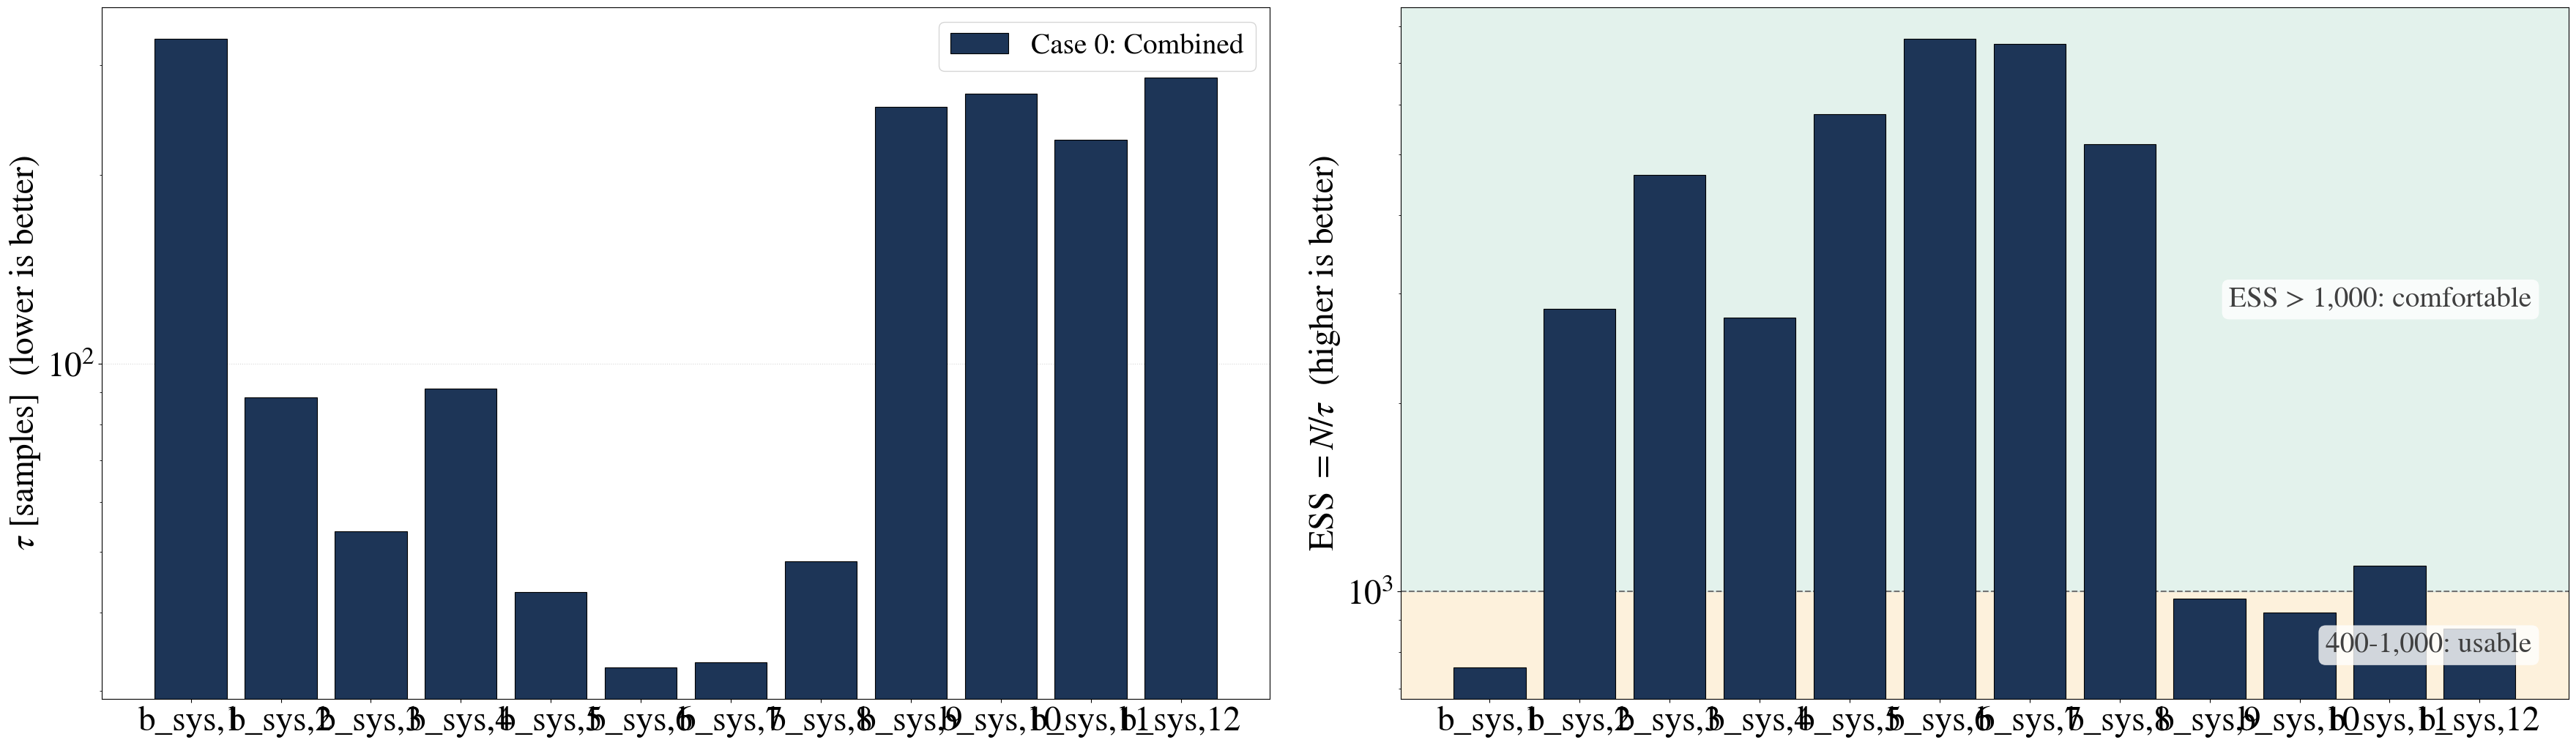

In [65]:
fig = tbl.plot_ess_tau(table1, colors=case_colors,
                       figsize=(max(20., 2.5 * Nsysmodes_max + 6.), 11))
save_fig(f'ess_tau_bsys{fig_suffix}.pdf')
print('Sampling efficiency of b_sys, (T1)')

---
### Table C1: convergence per parameter block

One row per case and monitored parameter block, summarised by its *worst*
scalar, because a block has only converged if all of its parameters have.

In [66]:
# ── Table C1: one row per case and monitored block ──────────────────────────
# Each block is summarised by its worst scalar (smallest ESS, largest Rhat,
# largest |Geweke z|), because a block has converged only if all of its
# parameters have.
_rows = []
for i in range(Ncases):
    for st in conv_stats[i]:
        min_ess  = _nanagg(np.nanmin, st['ess'])
        max_rhat = _nanagg(np.nanmax, st['rhat'])
        max_z    = _nanagg(np.nanmax, np.abs(st['z']))
        _rows.append(dict(
            case=case_labels_plain[i],
            block=conv_group_plain[st['group']],
            npar=len(st['labels']),
            max_tau=_nanagg(np.nanmax, st['tau']),
            min_ess=min_ess,
            min_ess_frac=_nanagg(np.nanmin, st['ess_frac']),
            med_ess_frac=_nanagg(np.nanmedian, st['ess_frac']),
            max_rhat=max_rhat,
            max_z=max_z,
            verdict=tbl.verdict(max_rhat, min_ess, max_z),
        ))

table_c1 = tbl.show(tbl.Table(
    _rows,
    [tbl.Col('case',  'Case',            fmt='{}', align='left'),
     tbl.Col('block', 'Parameter block', fmt='{}', align='left'),
     tbl.Col('npar',  'Scalars',         fmt='{:d}'),
     tbl.Col('max_tau',      'worst τ',      fmt='{:,.1f}'),
     tbl.Col('min_ess',      'worst ESS',    fmt='{:,.0f}', flag=tbl.flag_ess),
     tbl.Col('min_ess_frac', 'worst ESS/N',  fmt='{:.3f}',  flag=tbl.flag_ess_frac),
     tbl.Col('med_ess_frac', 'median ESS/N', fmt='{:.3f}'),
     tbl.Col('max_rhat',     'worst split-Rhat', fmt='{:.4f}', flag=tbl.flag_rhat),
     tbl.Col('max_z',        'worst |Geweke z|', fmt='{:.2f}', flag=tbl.flag_geweke),
     tbl.Col('verdict',      'Verdict', fmt='{}', align='center',
             flag=tbl.flag_verdict)],
    title='Table C1 — convergence diagnostics per parameter block',
    subtitle=(f'Post-burn-in chains ({CONV_BURN_TEXT}). Complex '
              f'parameters are split into their real and imaginary parts, and '
              f'each block is summarised by its worst scalar.'),
    notes=[
        '<b>ESS / N</b> is the sampling efficiency: the fraction of the '
        'iterations that count as independent draws. <b>split-Rhat</b> compares '
        f'{CONV_NSPLIT} consecutive segments of the chain with each other — '
        f'&le; {CONV_RHAT_OK} means they agree (converged). <b>Geweke z</b> '
        'compares the start of the chain with its end — |z| &le; '
        f'{CONV_Z_OK:.0f} means burn-in is complete.',
        '<b>Verdict</b> is "converged" when all three pass, "marginal" when one '
        'is only just outside its threshold, and "not converged" when any of '
        f'them fails badly (Rhat &gt; {tbl.RHAT_WARN}, ESS &lt; '
        f'{tbl.ESS_WARN:.0f}, or |z| &gt; {tbl.GEWEKE_WARN:.0f}).',
        'These statistics can only ever <i>detect</i> non-convergence; passing '
        'them is necessary, not sufficient.',
    ],
    name='tableC1_convergence_blocks', group_key='case'))

del _rows

Case,Parameter block,Scalars,worst τ,worst ESS,worst ESS/N,median ESS/N,worst split-Rhat,worst |Geweke z|,Verdict
Case 0: Combined,ln L (joint log-posterior),1,1.0,"222,766",0.990,0.990,1.0000,0.08,converged
Case 0: Combined,b_sys (systematic amplitudes),24,345.0,652,0.003,0.011,1.0040,2.33,marginal
Case 0: Combined,P_EoR (EoR DPS at systematic delays),8,5.0,"45,342",0.202,0.796,1.0001,1.66,converged
Case 0: Combined,a_fg (foreground amplitudes),20,1.4,"165,951",0.738,0.826,1.0000,2.48,marginal


---
### Figure C0: convergence dashboard → `convergence_dashboard*.pdf`

Table C1 as three heat maps — one cell per case and monitored block, with the
value printed on it.  Green is good in every panel: high efficiency (left),
$\hat{R}$ near 1 (middle), small $|z|$ (right).  The label under the middle and
right panels is the conventional threshold ($\hat{R} = 1.01$, $|z| = 2$).

  (SAVE_FIGS=False, not writing convergence_dashboard_conv.pdf)
Convergence dashboard, (C0)


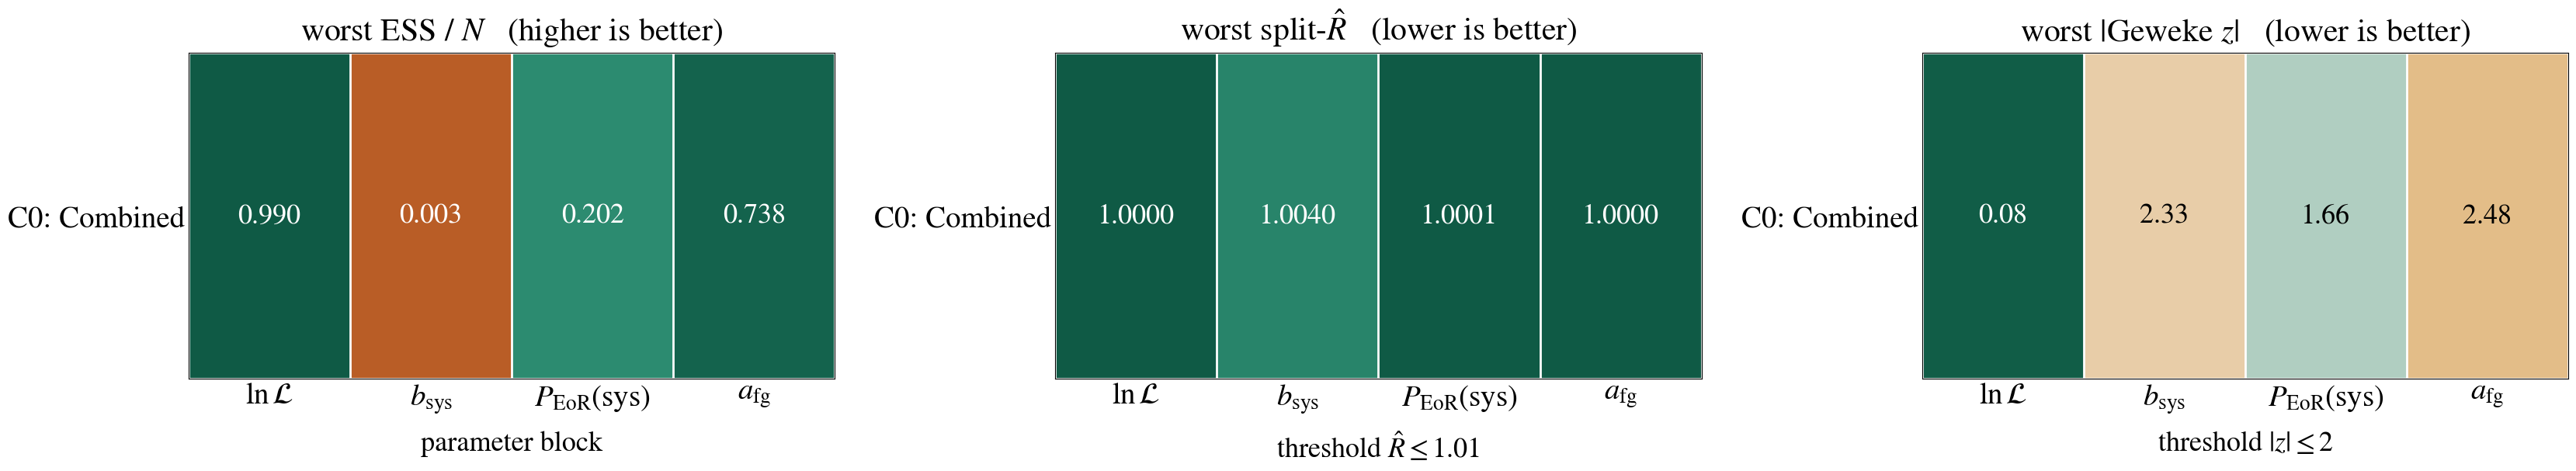

In [67]:
# ── Figure C0: convergence dashboard ────────────────────────────────────────
# One heat map per diagnostic; rows are cases, columns are monitored blocks.
_blocks       = [st['group'] for st in conv_stats[0]]
_block_labels = [conv_group_tex[g] for g in _blocks]
_case_rows    = [lab.replace('Case ', 'C') for lab in case_labels_plain]

def _block_matrix(reduce_fn, key, absolute=False):
    return np.array([[reduce_fn(np.abs(st[key]) if absolute else st[key])
                      for st in conv_stats[i]] for i in range(Ncases)])

M_eff  = _block_matrix(lambda v: _nanagg(np.nanmin, v), 'ess_frac')
M_rhat = _block_matrix(lambda v: _nanagg(np.nanmax, v), 'rhat')
M_z    = _block_matrix(lambda v: _nanagg(np.nanmax, v), 'z', absolute=True)

fig, axs = plt.subplots(1, 3, figsize=(34, 4.5 + 2.4 * Ncases))

tbl.annotated_heatmap(
    axs[0], M_eff, _case_rows, _block_labels, fmt='{:.3f}',
    cmap=tbl.quality_cmap(), norm=LogNorm(vmin=1e-3, vmax=1.),
    title=r'worst ESS / $N$   (higher is better)', fontsize=26,
    title_fontsize=30)

tbl.annotated_heatmap(
    axs[1], M_rhat, _case_rows, _block_labels, fmt='{:.4f}',
    cmap=tbl.quality_cmap(reverse=True), vmin=1., vmax=1. + 2. * (CONV_RHAT_OK - 1.),
    title=r'worst split-$\hat{R}$   (lower is better)', fontsize=26,
    title_fontsize=30)

tbl.annotated_heatmap(
    axs[2], M_z, _case_rows, _block_labels, fmt='{:.2f}',
    cmap=tbl.quality_cmap(reverse=True), vmin=0., vmax=2. * CONV_Z_OK,
    title=r'worst $|$Geweke $z|$   (lower is better)', fontsize=26,
    title_fontsize=30)

for ax in axs:
    ax.tick_params(labelsize=28)

# Mark the conventional thresholds on the colour scale of the last two panels.
axs[1].set_xlabel(rf'threshold $\hat{{R}} \leq {CONV_RHAT_OK}$', fontsize=26, labelpad=14)
axs[2].set_xlabel(rf'threshold $|z| \leq {CONV_Z_OK:.0f}$', fontsize=26, labelpad=14)
axs[0].set_xlabel('parameter block', fontsize=26, labelpad=14)

plt.tight_layout()
save_fig(f'convergence_dashboard{fig_suffix}.pdf')
print('Convergence dashboard, (C0)')

## Convergence summary and ranking

**Table C2** collapses every monitored scalar of a case into one row.  With more
than one case, **Table C3** turns those numbers into a ranking and the verdict
box under it answers *which case converged best*; with a single case the box is
simply that run's verdict.

The ranking uses three independent criteria — efficiency (worst
$N_\mathrm{eff}/N$), mixing (worst split-$\hat{R}$) and stationarity (fraction
of scalars failing $|z| < 2$) — each converted to a rank and averaged, so that
no single statistic decides the outcome on its own.  Efficiency is compared as
$N_\mathrm{eff}/N$ rather than as raw $N_\mathrm{eff}$ because the cases need
not have run for the same number of iterations.

**Table C4** names the bottleneck: the one monitored scalar in each case with
the lowest efficiency, which is what sets that case's "worst" columns.

In [68]:
# ── Tables C2 / C3 / C4: summary, ranking and bottleneck ────────────────────
# ESS/N (efficiency) rather than raw ESS is the fair comparison, because the
# cases need not have run for the same number of iterations.  Every case is
# scored by the *worst* monitored scalar it contains: a sampler is only
# converged if all of its parameters are.

summary = []
for i, run_ver in enumerate(run_version_arr):
    ess      = np.concatenate([s['ess']      for s in conv_stats[i]])
    ess_frac = np.concatenate([s['ess_frac'] for s in conv_stats[i]])
    tau      = np.concatenate([s['tau']      for s in conv_stats[i]])
    rhat     = np.concatenate([s['rhat']     for s in conv_stats[i]])
    zed      = np.abs(np.concatenate([s['z'] for s in conv_stats[i]]))
    rel      = np.concatenate([s['reliable'] for s in conv_stats[i]])
    summary.append(dict(
        case=i, run=run_ver, nfg=Nfgmodes_arr[i], label=case_labels_plain[i],
        n=Niter_all[i] - CONV_BURN_arr[i],
        min_ess_frac=_nanagg(np.nanmin, ess_frac),
        med_ess_frac=_nanagg(np.nanmedian, ess_frac),
        min_ess=_nanagg(np.nanmin, ess),
        max_tau=_nanagg(np.nanmax, tau),
        max_rhat=_nanagg(np.nanmax, rhat),
        n_rhat_bad=int(np.sum(rhat > CONV_RHAT_OK)),
        max_z=_nanagg(np.nanmax, zed),
        frac_z_bad=float(np.mean(zed[np.isfinite(zed)] > CONV_Z_OK)) if np.isfinite(zed).any() else np.nan,
        nparams=ess_frac.size,
        frac_unreliable=float(np.mean(~rel)),
    ))
    summary[-1]['verdict'] = tbl.verdict(summary[-1]['max_rhat'],
                                         summary[-1]['min_ess'],
                                         summary[-1]['max_z'])

table_c2 = tbl.show(tbl.Table(
    summary,
    [tbl.Col('label', 'Case',   fmt='{}', align='left'),
     tbl.Col('run',   'Run',    fmt='{}', align='left'),
     tbl.Col('n',     'N samples', fmt='{:,.0f}'),
     tbl.Col('nparams', 'Scalars', fmt='{:d}'),
     tbl.Col('max_tau', 'worst τ', fmt='{:,.1f}'),
     tbl.Col('min_ess', 'worst ESS', fmt='{:,.0f}', flag=tbl.flag_ess),
     tbl.Col('min_ess_frac', 'worst ESS/N', fmt='{:.4f}', flag=tbl.flag_ess_frac),
     tbl.Col('med_ess_frac', 'median ESS/N', fmt='{:.4f}'),
     tbl.Col('max_rhat', 'worst split-Rhat', fmt='{:.4f}', flag=tbl.flag_rhat),
     tbl.Col('n_rhat_bad', f'# Rhat > {CONV_RHAT_OK}', fmt='{:d}',
             flag=tbl.flag_le(0, 2)),
     tbl.Col('max_z', 'worst |z|', fmt='{:.2f}', flag=tbl.flag_geweke),
     tbl.Col('frac_z_bad', f'frac |z| > {CONV_Z_OK:.0f}', fmt='{:.2f}',
             flag=tbl.flag_le(0.0, 0.1)),
     tbl.Col('verdict', 'Verdict', fmt='{}', align='center', flag=tbl.flag_verdict)],
    title='Table C2 — convergence summary, one row per case',
    subtitle=(f'Every monitored scalar of a case, summarised by the worst one. '
              f'Burn-in: {CONV_BURN_TEXT}.'),
    notes=[
        'Columns headed "worst" are minima (ESS) or maxima (τ, Rhat, |z|) over '
        'all monitored scalars of that case, so one badly mixing parameter is '
        'enough to spoil the row — which is the intended behaviour.',
        f'"# Rhat &gt; {CONV_RHAT_OK}" and "frac |z| &gt; {CONV_Z_OK:.0f}" say '
        f'how widespread a problem is, rather than how bad its worst instance '
        f'is.',
    ],
    name='tableC2_convergence_summary'))

# ── Ranking ──────────────────────────────────────────────────────────────────
# Three independent criteria, each turned into a rank (1 = best) and averaged:
#   * efficiency   : worst ESS/N over all monitored scalars   (larger is better)
#   * mixing       : worst rank-normalised split-Rhat         (smaller is better)
#   * stationarity : fraction of scalars failing Geweke |z|<2 (smaller is better)
def _ranks(values, larger_is_better):
    v = np.asarray(values, dtype=float)
    v = np.where(np.isfinite(v), v, -np.inf if larger_is_better else np.inf)
    order = np.argsort(-v if larger_is_better else v, kind='stable')
    r = np.empty(v.size, dtype=float)
    r[order] = np.arange(v.size)
    return r

rank_eff  = _ranks([s['min_ess_frac'] for s in summary], True)
rank_rhat = _ranks([s['max_rhat']     for s in summary], False)
rank_z    = _ranks([s['frac_z_bad']   for s in summary], False)
rank_avg  = (rank_eff + rank_rhat + rank_z) / 3.
best      = int(np.argmin(rank_avg))

# A ranking of one case says nothing, so it is only built when there is
# something to compare.
table_c3 = None
if Ncases > 1:
    _rank_rows = [dict(
        label=summary[i]['label'],
        eff=rank_eff[i] + 1, mixing=rank_rhat[i] + 1, stat=rank_z[i] + 1,
        mean=rank_avg[i] + 1, place=('best' if i == best else ''),
    ) for i in range(Ncases)]
    _rank_rows.sort(key=lambda r: r['mean'])

    table_c3 = tbl.show(tbl.Table(
        _rank_rows,
        [tbl.Col('label',  'Case', fmt='{}', align='left'),
         tbl.Col('eff',    'Efficiency rank',    fmt='{:.0f}'),
         tbl.Col('mixing', 'Mixing rank',        fmt='{:.0f}'),
         tbl.Col('stat',   'Stationarity rank',  fmt='{:.0f}'),
         tbl.Col('mean',   'Mean rank',          fmt='{:.2f}'),
         tbl.Col('place',  '', fmt='{}', align='center',
                 flag=lambda v: 'good' if v else None)],
        title='Table C3 — ranking of the cases (1 = best)',
        subtitle=('Efficiency = worst ESS/N; mixing = worst split-Rhat; '
                  'stationarity = fraction of scalars with |Geweke z| above '
                  f'{CONV_Z_OK:.0f}. The three ranks are averaged with equal weight.'),
        name='tableC3_convergence_ranking'))
    del _rank_rows
else:
    print('Single case: no ranking to build (Table C3 skipped).')

# ── The take-home sentence ───────────────────────────────────────────────────
_b = summary[best]
_kind = tbl.VERDICT_FLAG[_b['verdict']]
_head = (f"<b>Best-converged case: {_b['label']}</b>" if Ncases > 1
         else f"<b>{_b['label']}</b>")
_msg = (f"{_head} (run <code>{_b['run']}</code>, "
        f"N<sub>fg</sub> = {_b['nfg']}).<br>"
        f"Worst of its {_b['nparams']} monitored scalars: "
        f"ESS = {_b['min_ess']:,.0f} of {_b['n']:,} samples "
        f"(efficiency {_b['min_ess_frac']:.4f}), "
        f"split-Rhat = {_b['max_rhat']:.4f}, |Geweke z| = {_b['max_z']:.2f} "
        f"&rarr; <b>{_b['verdict']}</b>.")
if _b['max_rhat'] > CONV_RHAT_OK:
    _msg += (f"<br><b>Caution:</b> "
             + (f"even the best case has split-Rhat above {CONV_RHAT_OK}, so no "
                f"case is fully converged by that criterion."
                if Ncases > 1 else
                f"split-Rhat is above {CONV_RHAT_OK}, so this run is not fully "
                f"converged by that criterion."))
tbl.callout(_msg, kind=_kind, title='Verdict')

# ── Slowest-mixing scalar in each case ───────────────────────────────────────
_slow_rows = []
for i in range(Ncases):
    labels = sum([s['labels'] for s in conv_stats[i]], [])
    ess_f  = np.concatenate([s['ess_frac'] for s in conv_stats[i]])
    ess    = np.concatenate([s['ess']      for s in conv_stats[i]])
    taus   = np.concatenate([s['tau']      for s in conv_stats[i]])
    k = int(np.nanargmin(np.where(np.isfinite(ess_f), ess_f, np.inf)))
    _slow_rows.append(dict(label=case_labels_plain[i], param=labels[k],
                           tau=taus[k], ess=ess[k], ess_frac=ess_f[k]))

table_c4 = tbl.show(tbl.Table(
    _slow_rows,
    [tbl.Col('label', 'Case', fmt='{}', align='left'),
     tbl.Col('param', 'Slowest scalar', fmt='{}', align='left'),
     tbl.Col('tau', 'τ [samples]', fmt='{:,.1f}'),
     tbl.Col('ess', 'ESS', fmt='{:,.0f}', flag=tbl.flag_ess),
     tbl.Col('ess_frac', 'ESS / N', fmt='{:.4f}', flag=tbl.flag_ess_frac)],
    title='Table C4 — the bottleneck parameter of each case',
    subtitle=('The single monitored scalar with the lowest efficiency; it is '
              'this parameter that sets the "worst" columns of Table C2, and '
              'the one to watch if a case needs a longer run.'),
    name='tableC4_slowest_scalar'))

del _slow_rows

Case,Run,N samples,Scalars,worst τ,worst ESS,worst ESS/N,median ESS/N,worst split-Rhat,# Rhat > 1.01,worst |z|,frac |z| > 2,Verdict
Case 0: Combined,caseiv,"225,000",53,345.0,652,0.0029,0.7376,1.0040,0,2.48,0.08,marginal


Single case: no ranking to build (Table C3 skipped).


Case,Slowest scalar,τ [samples],ESS,ESS / N
Case 0: Combined,Re b_sys[0],345.0,652,0.0029


## Convergence is not accuracy

A chain can mix perfectly and still sit on the wrong answer.  **Table C5**
separates the two for every systematic amplitude of every case that supplied a
`sys_amps_true`:

* $|\mathrm{bias}|/\sigma$ — how far the posterior mean sits from the truth, in
  units of the posterior scatter.  This is a property of the **model**: how well
  it lets the sampler separate foregrounds from systematics.  A well-specified
  model gives $\lesssim 1$; the table flags $>3$ in red.
* $\mathrm{MCSE}/\sigma$ — the Monte Carlo noise left on that posterior mean,
  i.e. how much of the offset the **chain length** could explain.  Values of a
  few per cent mean the offset is real and not a sampling fluctuation.

Read the two together: a large $|\mathrm{bias}|/\sigma$ with a small
$\mathrm{MCSE}/\sigma$ is a **model** problem that a longer run will not fix.

In [69]:
# ── Table C5: convergence is not accuracy ───────────────────────────────────
# For every systematic amplitude: how far the posterior mean is from the truth
# in units of the posterior scatter, together with the Monte Carlo error on
# that mean.  bias/sd is a property of the model (how well the foreground model
# lets the sampler separate foregrounds from systematics); MCSE/sd is a
# property of the chain (how long it ran).

_rows = []
for i, run_ver in enumerate(run_version_arr):
    if sys_amps_true_arr[i] is None:
        print(f'  {run_ver}: no sys_amps_true given, skipped')
        continue
    b  = np.asarray(conv_chains[i]['b_sys'])
    st = [s for s in conv_stats[i] if s['group'] == 'b_sys'][0]
    for k in range(Nsysmodes_arr[i]):
        for part, tag in ((np.real, 'Re'), (np.imag, 'Im')):
            col   = part(b[:, k])
            truth = part(sys_amps_true_arr[i][k])
            sd    = col.std(ddof=1)
            j     = 2 * k + (0 if tag == 'Re' else 1)
            _rows.append(dict(
                case=case_labels_plain[i],
                mode=f'{tag} b_sys,{k + 1}',
                truth=truth,
                mean=col.mean(),
                sd=sd,
                bias_sd=abs(col.mean() - truth) / sd,
                mcse_sd=st['mcse'][j] / sd,
                ess=st['ess'][j],
            ))

table_c5 = None
if _rows:
    table_c5 = tbl.show(tbl.Table(
        _rows,
        [tbl.Col('case', 'Case', fmt='{}', align='left'),
         tbl.Col('mode', 'Amplitude', fmt='{}', align='left'),
         tbl.Col('truth', 'Truth', fmt='{:+.2f}'),
         tbl.Col('mean',  'Posterior mean', fmt='{:+.3f}'),
         tbl.Col('sd',    'Posterior σ', fmt='{:.4f}'),
         tbl.Col('bias_sd', '|bias| / σ', fmt='{:.2f}', flag=tbl.flag_bias),
         tbl.Col('mcse_sd', 'MCSE / σ',   fmt='{:.4f}', flag=tbl.flag_mcse),
         tbl.Col('ess', 'ESS', fmt='{:,.0f}', flag=tbl.flag_ess)],
        title='Table C5 — accuracy of the recovered systematic amplitudes',
        subtitle=('Posterior mean of every systematic amplitude against the truth '
                  'used in the simulation, in units of the posterior scatter σ.'),
        notes=[
            '<b>|bias| / σ</b> is a property of the <i>model</i>: how well it '
            'lets the sampler separate foregrounds from systematics. '
            'Green &le; 1σ, amber &le; 3σ, red beyond.',
            '<b>MCSE / σ</b> is a property of the <i>chain</i>: the Monte Carlo '
            'noise still sitting on the posterior mean. When MCSE/σ is a few per '
            'cent and |bias|/σ is several σ, the offset is real and running the '
            'chain for longer will not remove it.',
        ],
        name='tableC5_bias_vs_mcse', group_key='case'))
else:
    print('No case supplied sys_amps_true: Table C5 and Figure C6 skipped.')

del _rows

Case,Amplitude,Truth,Posterior mean,Posterior σ,|bias| / σ,MCSE / σ,ESS
Case 0: Combined,"Re b_sys,1",+1.00,+1.012,0.0012,10.30,0.0392,652
Case 0: Combined,"Im b_sys,1",+4.00,+3.993,0.0011,6.48,0.0374,716
Case 0: Combined,"Re b_sys,2",+2.00,+1.996,0.0004,8.49,0.0190,"2,761"
Case 0: Combined,"Im b_sys,2",+3.00,+3.001,0.0004,2.69,0.0204,"2,409"
Case 0: Combined,"Re b_sys,3",+3.00,+2.999,0.0004,1.43,0.0154,"4,243"
Case 0: Combined,"Im b_sys,3",+2.00,+2.004,0.0004,10.55,0.0155,"4,139"
Case 0: Combined,"Re b_sys,4",+4.00,+3.999,0.0006,1.18,0.0196,"2,599"
Case 0: Combined,"Im b_sys,4",+1.00,+1.004,0.0006,6.46,0.0209,"2,300"
Case 0: Combined,"Re b_sys,5",+4.00,+3.999,0.0004,4.00,0.0140,"5,132"
Case 0: Combined,"Im b_sys,5",+6.00,+5.999,0.0004,2.55,0.0136,"5,424"


---
### Figure C6: bias against Monte Carlo error → `bias_mcse*.pdf`

Table C5 drawn.  Left: $|\mathrm{bias}|/\sigma$ per systematic amplitude, one
bar per case; the shading marks $1\sigma$ (acceptable) and $3\sigma$ (a clear
model bias).  Right: the Monte Carlo error on the same posterior means, in the
same units — when everything here sits far below the bias on the left, the left
panel is a statement about the model rather than about the run length.

Cases with different numbers of systematic modes share the x-axis; a case
simply has no bar where it has no such mode.

  (SAVE_FIGS=False, not writing bias_mcse_conv.pdf)
Bias against Monte Carlo error, (C6)


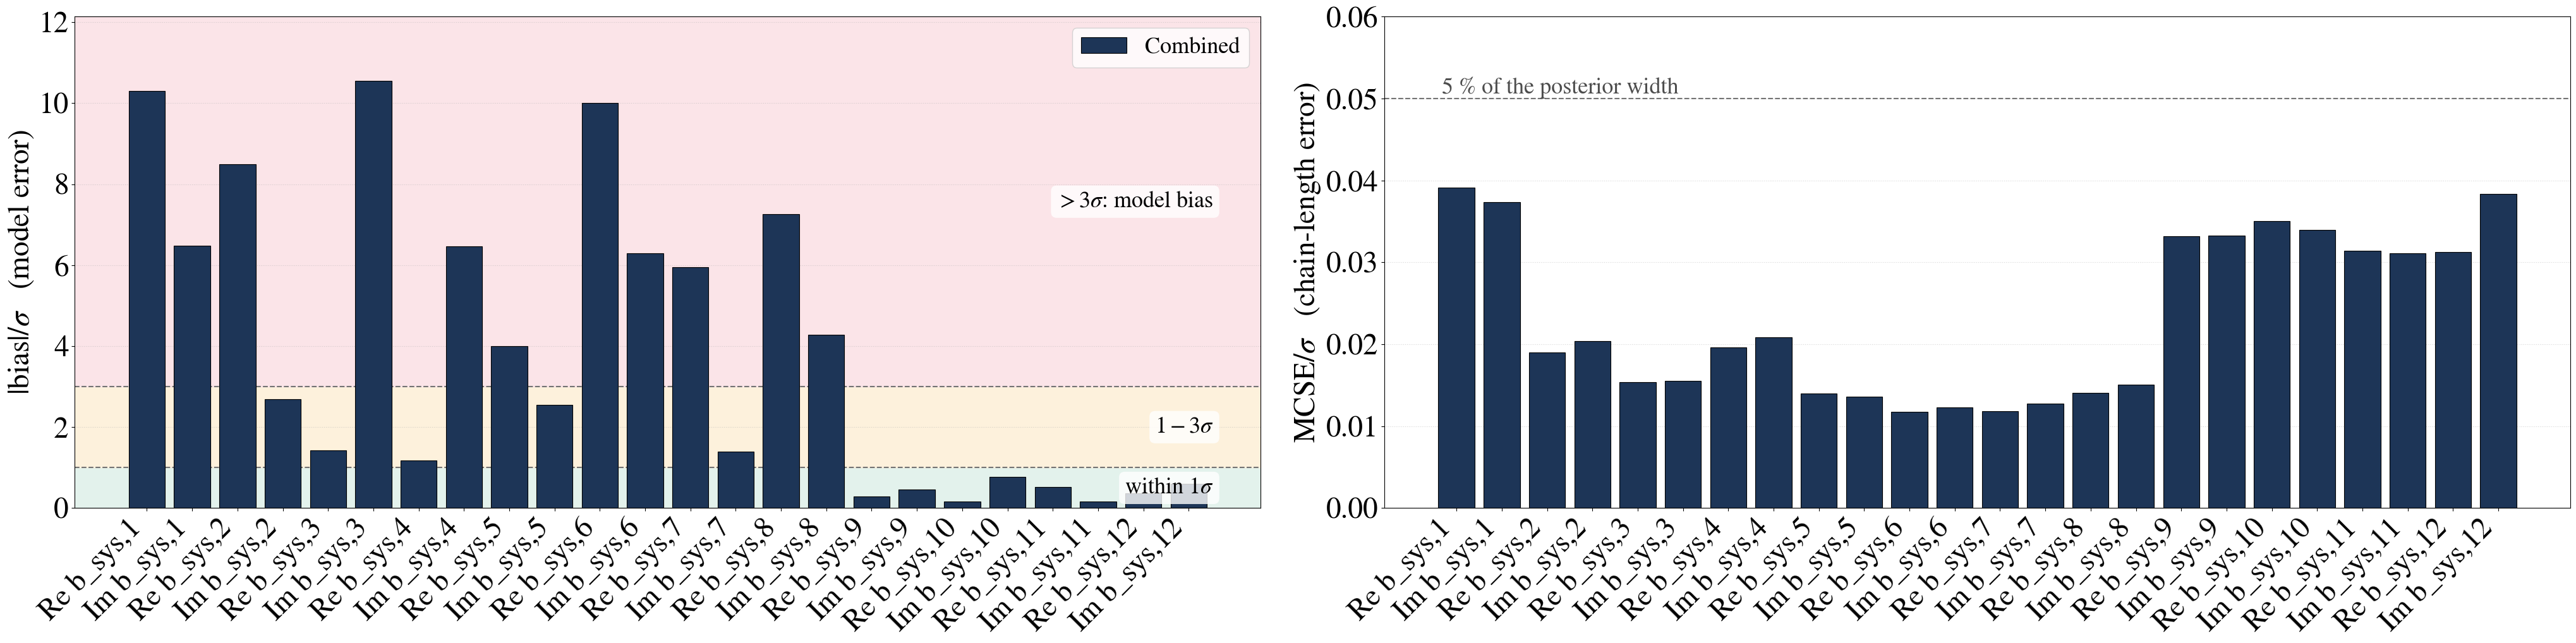

In [70]:
# ── Figure C6: |bias| / sigma and MCSE / sigma per systematic amplitude ─────
if table_c5 is None:
    print('Table C5 was skipped, so Figure C6 is skipped too.')
else:
    # The x-axis is the union of the amplitudes over all cases, so cases with
    # different numbers of systematic modes can share it.
    _cases_c5 = [lab for lab in case_labels_plain
                 if any(r['case'] == lab for r in table_c5.rows)]
    _modes = []
    for r in table_c5.rows:
        if r['mode'] not in _modes:
            _modes.append(r['mode'])
    _lut = {(r['case'], r['mode']): r for r in table_c5.rows}

    _x = np.arange(len(_modes), dtype=float)
    _w = 0.8 / len(_cases_c5)

    fig, axs = plt.subplots(1, 2, figsize=(max(32., 1.4 * len(_modes) + 8.), 11))

    for j, lab in enumerate(_cases_c5):
        i    = case_labels_plain.index(lab)
        off  = (j - (len(_cases_c5) - 1) / 2) * _w
        bias = [_lut.get((lab, m), {}).get('bias_sd', np.nan) for m in _modes]
        mcse = [_lut.get((lab, m), {}).get('mcse_sd', np.nan) for m in _modes]
        axs[0].bar(_x + off, bias, _w, color=case_colors[i],
                   edgecolor='black', linewidth=0.8, label=case_labels[i])
        axs[1].bar(_x + off, mcse, _w, color=case_colors[i],
                   edgecolor='black', linewidth=0.8, label=case_labels[i])

    # Quality bands on the bias panel: <= 1 sigma acceptable, <= 3 sigma marginal.
    _top = max(3.5, 1.15 * max(r['bias_sd'] for r in table_c5.rows))
    for y0, y1, colr in ((0., 1., tbl.C_GOOD), (1., 3., tbl.C_WARN), (3., _top, tbl.C_BAD)):
        axs[0].axhspan(y0, y1, color=colr, zorder=0)
    for y in (1., 3.):
        axs[0].axhline(y, color='0.45', ls='--', lw=1.5, zorder=0.5)
    axs[0].set_ylim(0, _top)
    axs[0].set_ylabel(r'$|\mathrm{bias}| / \sigma$   (model error)')
    axs[0].text(len(_modes) - 0.45, 0.5, r'within $1\sigma$', ha='right', va='center',
                fontsize=26, bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.8))
    axs[0].text(len(_modes) - 0.45, 2.0, r'$1-3\sigma$', ha='right', va='center',
                fontsize=26, bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.8))
    axs[0].text(len(_modes) - 0.45, (3. + _top) / 2, r'$> 3\sigma$: model bias', ha='right',
                va='center', fontsize=26,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.8))

    axs[1].set_ylabel(r'$\mathrm{MCSE} / \sigma$   (chain-length error)')
    axs[1].axhline(0.05, color='0.45', ls='--', lw=1.5)
    axs[1].text(-0.45, 0.05, ' 5 % of the posterior width', ha='left',
                va='bottom', fontsize=26, color='0.3')
    axs[1].set_ylim(0, max(0.06, 1.3 * max(r['mcse_sd'] for r in table_c5.rows)))

    for ax in axs:
        ax.set_xticks(_x)
        ax.set_xticklabels(_modes, rotation=45, ha='right')
        ax.grid(axis='y', ls=':', alpha=0.5)
        ax.set_axisbelow(True)
    axs[0].legend(fontsize=26, ncol=min(len(_cases_c5), 4))

    plt.tight_layout()
    save_fig(f'bias_mcse{fig_suffix}.pdf')
    print('Bias against Monte Carlo error, (C6)')

---
### Figure C1: traces and running means → `convergence_traces*.pdf`

The visual check behind the numbers.  Top: the log-posterior trace of each case
(relative to its own median, since the absolute value depends on the model) —
look for drift or long excursions.  Middle and bottom: $\mathrm{Re}\,
b_{\mathrm{sys},1}$ and $P_\mathrm{EoR}$ at the first systematic delay.

Set `TRACE_RUNNING_MEAN = True` in the configuration cell to plot the running
means of the lower two panels instead of the raw traces: a converged chain's
running mean flattens out, while one that is still wandering at the end of the
run has not converged.  `TRACE_WINDOW` restricts all three panels to a slice of
the post-burn-in chain.

  (SAVE_FIGS=False, not writing convergence_traces_conv.pdf)
Convergence traces, (C1)


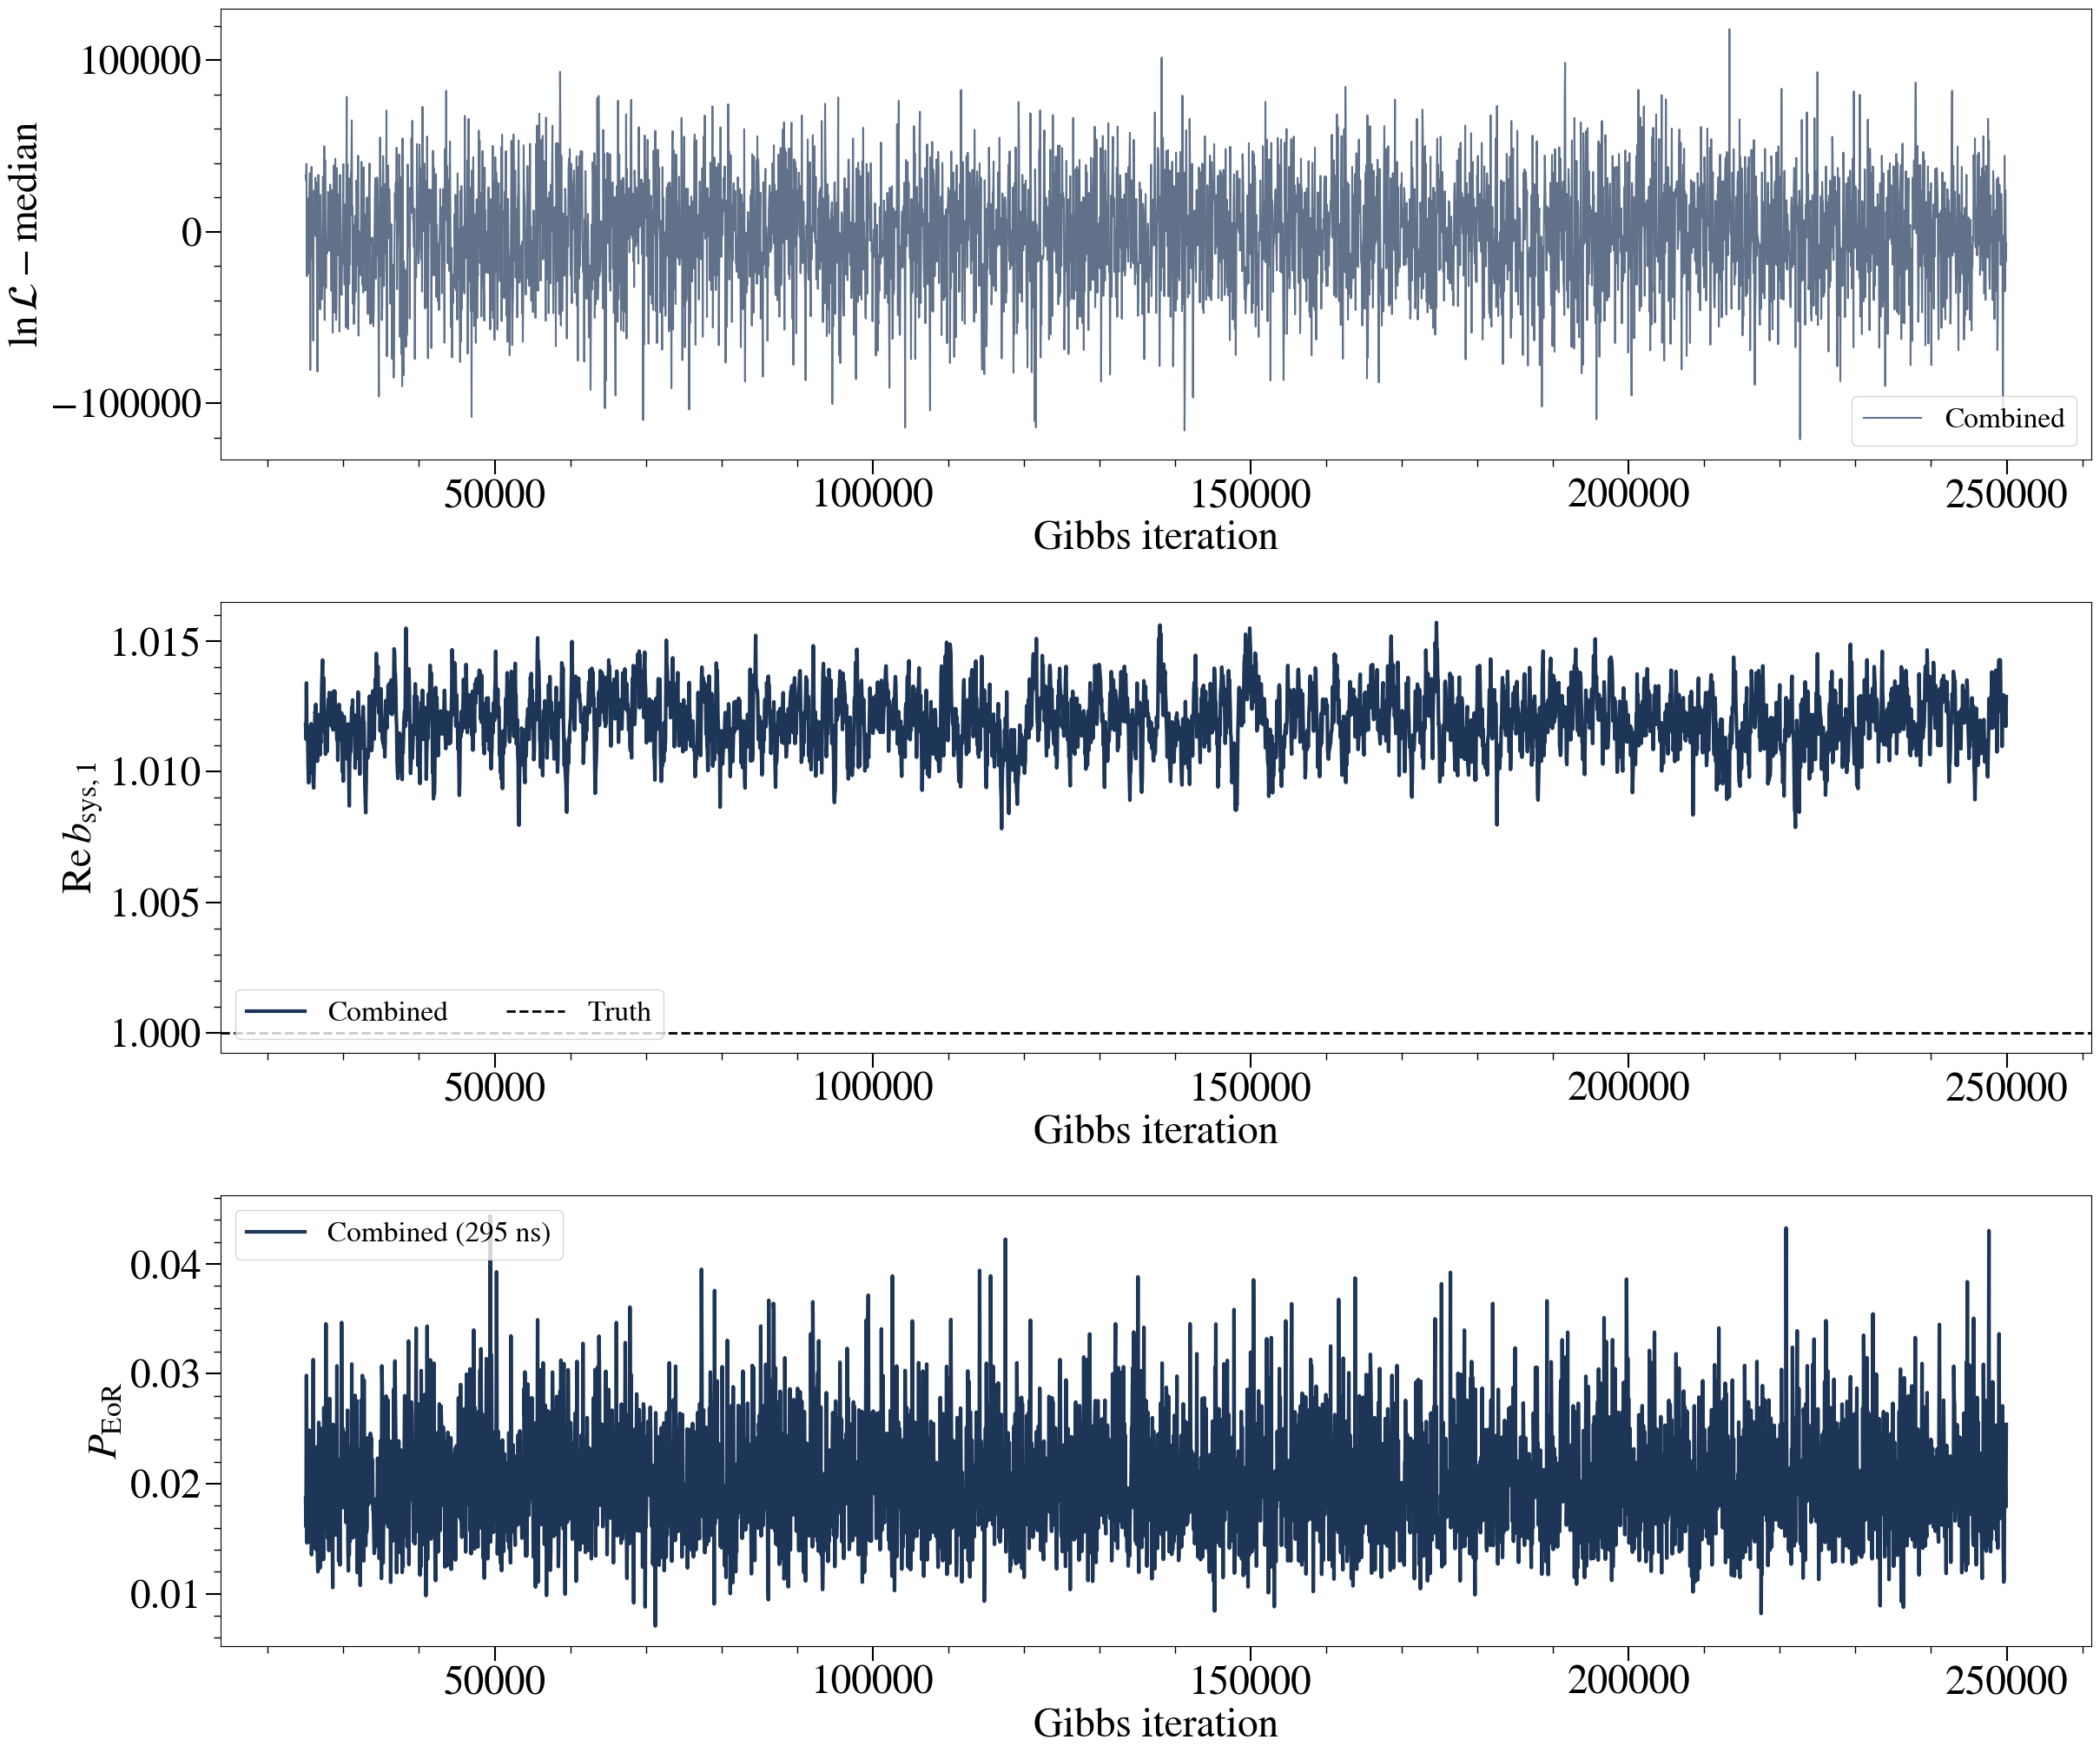

In [71]:
def _running_mean(x):
    x = np.asarray(x, dtype=float)
    return np.cumsum(x) / np.arange(1, x.size + 1)


def _thin(n, nmax=4000):
    return slice(None, None, max(1, n // nmax))


def _trace_window(i):
    """(start, stop) of the plotted slice within case `i`'s post-burn-in chain."""
    n = Niter_all[i] - CONV_BURN_arr[i]
    if TRACE_WINDOW is None:
        return 0, n
    start, stop = TRACE_WINDOW
    return int(np.clip(start, 0, n)), int(np.clip(stop, 0, n))


def _trace_plot(ax, i, y, label=None):
    """Plot one case's series against its absolute Gibbs-iteration number."""
    start, _ = _trace_window(i)
    x = np.arange(y.size) + CONV_BURN_arr[i] + start
    s = _thin(y.size)
    ax.plot(x[s], y[s], color=case_colors[i], lw=3,
            label=label if label is not None else case_labels[i])


fig, axs = plt.subplots(3, 1, figsize=(25, 21))

# --------------- log-posterior trace ----------------
# The absolute value of ln L depends on the model, so each case is shown
# relative to its own median: what matters here is the shape of the trace
# (drift, sticking, excursions), not the offset between cases.
for i in range(Ncases):
    a, b = _trace_window(i)
    y = np.asarray(conv_chains[i]['ln_post'], dtype=float).reshape(-1)[a:b]
    y = y - np.median(y)
    x = np.arange(y.size) + CONV_BURN_arr[i] + a
    s = _thin(y.size)
    axs[0].plot(x[s], y[s], color=case_colors[i], lw=1.5, alpha=0.7,
                label=case_labels[i])
axs[0].set_ylabel(r'$\ln \mathcal{L} - \mathrm{median}$')
axs[0].legend(fontsize=24, ncol=Ncases, loc='lower right')

# --------------- Re b_sys,1 ----------------
for i in range(Ncases):
    a, b = _trace_window(i)
    v = np.asarray(conv_chains[i]['b_sys'])[a:b, 0].real
    _trace_plot(axs[1], i, _running_mean(v) if TRACE_RUNNING_MEAN else v)
# The truth line is only meaningful when every case shares the same b_sys,1.
_truths_0 = {complex(t[0]) for t in sys_amps_true_arr if t is not None}
if len(_truths_0) == 1:
    axs[1].axhline(_truths_0.pop().real, color='k', ls='--', lw=2, label='Truth')
axs[1].set_ylabel(r'$\langle \mathrm{Re}\, b_{\mathrm{sys},1} \rangle$'
                  if TRACE_RUNNING_MEAN else r'$\mathrm{Re}\, b_{\mathrm{sys},1}$')
axs[1].legend(fontsize=24, ncol=Ncases + 1, loc='best')

# --------------- P_EoR at the first systematic delay ----------------
# Each case is shown at its own first systematic delay, which need not be the
# same bin in every case, so the delay is named in the legend.
for i in range(Ncases):
    a, b = _trace_window(i)
    dl0 = int(sys_dl_idx_arr[i][0])
    p   = np.asarray(dps_post_all[i])[a:b, dl0]
    _trace_plot(axs[2], i, _running_mean(p) if TRACE_RUNNING_MEAN else p,
                label=f'{case_labels[i]} ({delays_ns[dl0]:.0f} ns)')
axs[2].set_ylabel(r'$\langle P_\mathrm{EoR} \rangle$' if TRACE_RUNNING_MEAN
                  else r'$P_\mathrm{EoR}$')
axs[2].legend(fontsize=24, ncol=Ncases, loc='best')

for ax in axs:
    ax.set_xlabel('Gibbs iteration')
    ax.minorticks_on()
    ax.tick_params(which='major', direction='out', length=12, width=1.5)
    ax.tick_params(which='minor', direction='out', length=6, width=1.0)

plt.tight_layout()
save_fig(f'convergence_traces{fig_suffix}.pdf')
print('Convergence traces, (C1)')

---
### Figure C2: autocorrelation and efficiency → `convergence_acf_ess*.pdf`

Left: the autocorrelation function of $b_\mathrm{sys}$ (averaged over the real
and imaginary parts of all of a case's amplitudes) — how many iterations each
case needs to forget its previous sample.  Right: the worst efficiency
$N_\mathrm{eff}/N$ in each monitored block, per case.

  (SAVE_FIGS=False, not writing convergence_acf_ess_conv.pdf)
b_sys autocorrelation and per-block efficiency, (C2)


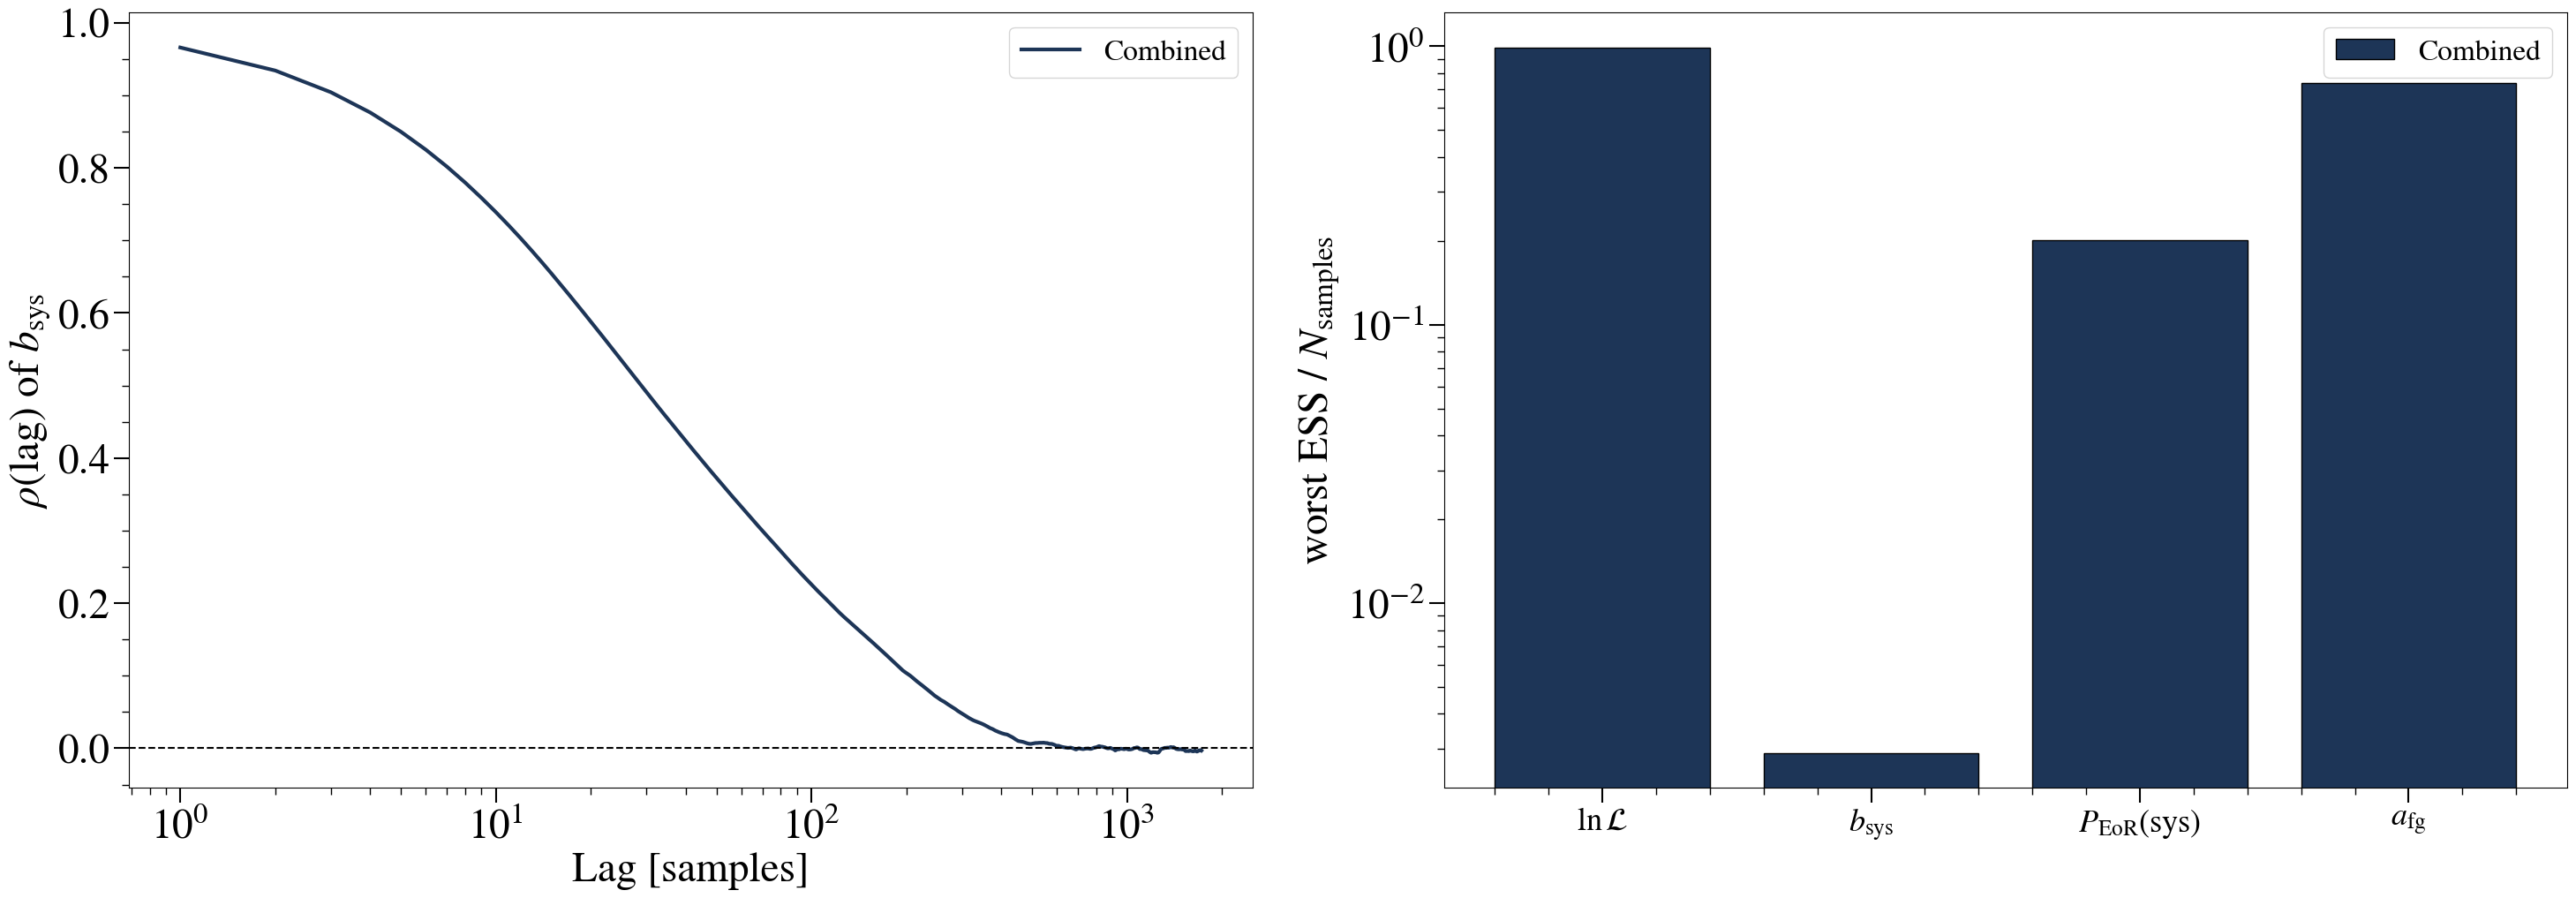

In [72]:
fig, axs = plt.subplots(1, 2, figsize=(30, 11))

# --------------- autocorrelation of b_sys ----------------
# Mean over the real and imaginary parts of all systematic amplitudes, so one
# curve per case summarises how fast that case forgets its previous sample.
maxlag = 1
acfs   = []
for i in range(Ncases):
    cols, _ = real_columns(conv_chains[i]['b_sys'], 'b')
    acf = np.mean([emcee.autocorr.function_1d(cols[:, k]) for k in range(cols.shape[1])], axis=0)
    acfs.append(acf)
    tau_max = _nanagg(np.nanmax, np.concatenate(
        [s['tau'] for s in conv_stats[i] if s['group'] == 'b_sys']))
    maxlag = max(maxlag, int(5 * tau_max) if np.isfinite(tau_max) else 100)
maxlag = int(np.clip(maxlag, 50, min(len(a) for a in acfs)))

for i, acf in enumerate(acfs):
    axs[0].plot(np.arange(1, maxlag), acf[1:maxlag], color=case_colors[i], lw=3,
                label=case_labels[i])
axs[0].axhline(0, color='k', ls='--', lw=1.5)
axs[0].set_xscale('log')       # the mixing times differ by orders of magnitude
axs[0].set_xlabel('Lag [samples]')
axs[0].set_ylabel(r'$\rho(\mathrm{lag})$ of $b_\mathrm{sys}$')
axs[0].legend(fontsize=24)

# --------------- efficiency per monitored block ----------------
groups = [conv_group_tex[s['group']] for s in conv_stats[0]]
xpos   = np.arange(len(groups))
width  = 0.8 / Ncases
for i in range(Ncases):
    vals = [_nanagg(np.nanmin, s['ess_frac']) for s in conv_stats[i]]
    axs[1].bar(xpos + (i - (Ncases - 1) / 2.) * width, vals, width,
               color=case_colors[i], edgecolor='k', label=case_labels[i])
axs[1].set_xticks(xpos)
axs[1].set_xticklabels(groups, fontsize=26)
axs[1].set_ylabel(r'worst ESS / $N_\mathrm{samples}$')
axs[1].set_yscale('log')
axs[1].legend(fontsize=24)

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(which='major', direction='out', length=12, width=1.5)
    ax.tick_params(which='minor', direction='out', length=6, width=1.0)

plt.tight_layout()
save_fig(f'convergence_acf_ess{fig_suffix}.pdf')
print('b_sys autocorrelation and per-block efficiency, (C2)')

---
### Figure C3: EoR power-spectrum efficiency per delay → `convergence_ess_dps*.pdf`

Efficiency of the sampled EoR delay power spectrum, delay bin by delay bin.  The
dotted lines and shaded band mark the delays occupied by the systematics (the
union over all cases), where the degeneracy between the foreground model and the
systematics model is strongest and where mixing is therefore expected to be
slowest.

  (SAVE_FIGS=False, not writing convergence_ess_dps_conv.pdf)
EoR delay-power-spectrum sampling efficiency, (C3)


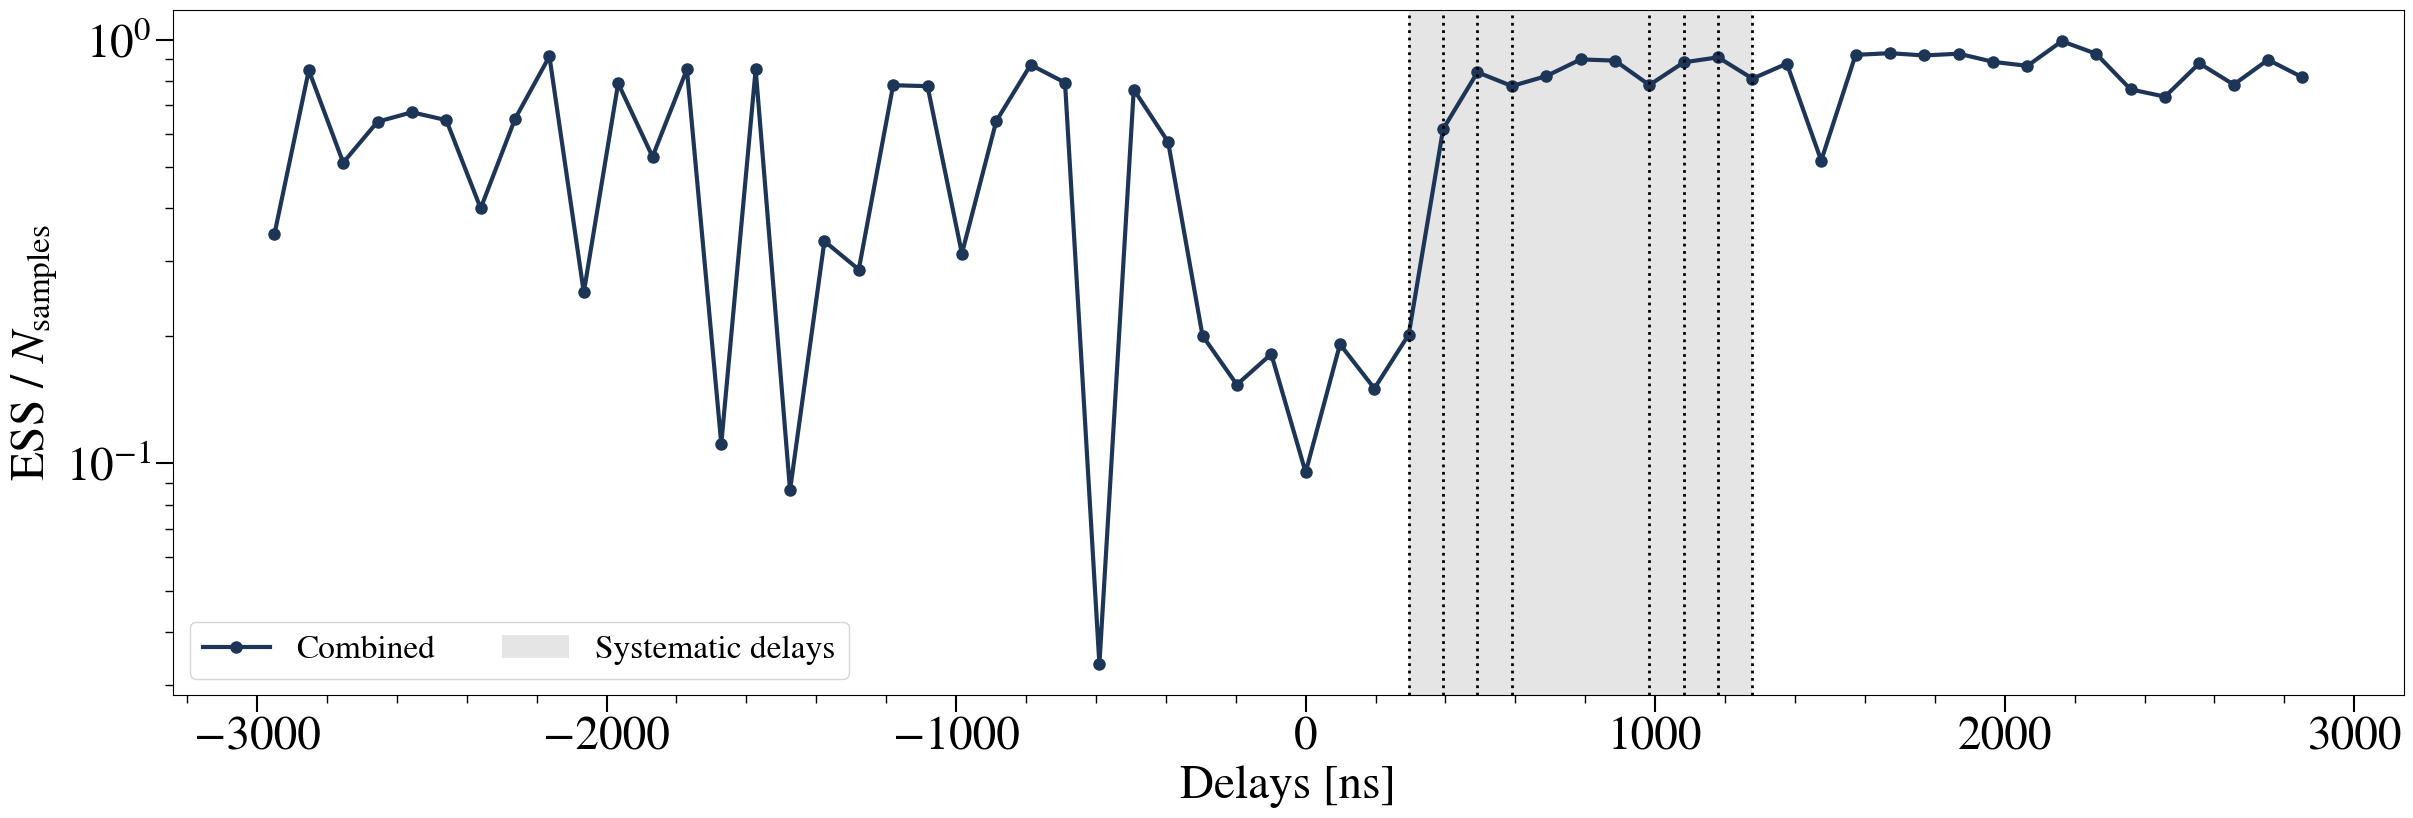

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(25, 9))

_n_dps = np.array([Niter_all[i] - CONV_BURN_arr[i] for i in range(Ncases)], dtype=float)
for i in range(Ncases):
    ax.plot(delays.value, ess_dps_all[i] / _n_dps[i], marker='o', ms=8, lw=3,
            color=case_colors[i], label=case_labels[i])

for dl in delays_ns[sys_dl_idx_union]:
    ax.axvline(dl, color='k', ls=':', lw=2)
ax.axvspan(delays_ns[sys_dl_idx_union].min(), delays_ns[sys_dl_idx_union].max(),
           facecolor='grey', alpha=0.2, zorder=0.1, label='Systematic delays')

ax.set_yscale('log')
ax.set_xlabel('Delays [ns]')
ax.set_ylabel(r'ESS / $N_\mathrm{samples}$')
ax.legend(fontsize=24, ncol=Ncases + 1)
ax.minorticks_on()
ax.tick_params(which='major', direction='out', length=12, width=1.5)
ax.tick_params(which='minor', direction='out', length=6, width=1.0)

plt.tight_layout()
save_fig(f'convergence_ess_dps{fig_suffix}.pdf')
print('EoR delay-power-spectrum sampling efficiency, (C3)')

---
# Raftery-Lewis run-length diagnostic

The diagnostics above ask *has this chain converged?*  Raftery & Lewis (1992)
asks the complementary question: **how long would this chain have to be?**

It fixes a concrete estimation target — the $q$-th posterior quantile, to be
estimated within $\pm r$ with probability $s$ — and returns the number of
iterations needed to hit it:

* $N_\mathrm{min}$ — iterations needed if the draws were **independent**,
  $N_\mathrm{min} = \left[\Phi^{-1}\!\left(\tfrac{s+1}{2}\right)\sqrt{q(1-q)}\,/\,r\right]^2$.
  With the defaults ($q = 0.025$, $r = 0.005$, $s = 0.95$) this is 3746.
* $M$ — the **burn-in** the chain needs before it is close enough to
  stationarity.
* $N$ — the **post-burn-in** iterations needed for the required accuracy.
* $I = (M + N)/N_\mathrm{min}$ — the **dependence factor**, how much the
  autocorrelation inflates the requirement.  $I \approx 1$ means the sampler is
  as good as independent; $I \gtrsim 5$ is the usual flag for strong
  dependence.

The method reduces the chain to the indicator $Z_t = \mathbb{1}\{\theta_t \le
u_q\}$, thins it until a two-state **first-order** Markov chain fits better than
a second-order one (by BIC), and reads $M$ and $N$ off that two-state chain's
transition probabilities $\alpha = P(0\!\to\!1)$ and $\beta = P(1\!\to\!0)$.

**Why this is written out here.**  There is no library route in this
environment.  `pymc` 5.x and `arviz` no longer contain the diagnostic at all
(the PyMC2-era `pymc.raftery_lewis` is gone, and modern PyMC delegates its
statistics to ArviZ, which never had it); `rpy2` + `coda::raftery.diag` would
need a full R installation, and there is no R on this machine; and no
maintained pure-Python implementation exists on PyPI.  So the algorithm below
is implemented directly from the paper.

$q$, $r$ and $s$ are taken from `RL_Q`, `RL_R`, `RL_S` in the configuration
cell — they are arguments, not constants, because they *are* the question being
asked: a tail quantile or a tighter tolerance needs a longer run.

> **Note on burn-in.**  Unlike every table above, this section reads the
> **full raw chains, including the burn-in**, using the same `cases`
> configuration and the same files as the loader cell.  It has to: the whole
> point is to estimate the burn-in a run needed, which can then be compared
> against the `CONV_BURN` actually applied.

In [74]:
# ── Raftery-Lewis run-length diagnostic ──────────────────────────────────────
# Implemented from the paper (see `raftery_lewis` below); no dependency beyond
# numpy/scipy, which is what the rest of this notebook already uses.


def raftery_lewis_nmin(q=RL_Q, r=RL_R, s=RL_S):
    """
    Iterations that would be needed if the draws were independent.

    Raftery & Lewis (1992), section 2:
    ``Nmin = [Phi^-1((s+1)/2) * sqrt(q(1-q)) / r]^2``.

    Parameters
    ----------
    q, r, s : float
        Quantile to estimate, required accuracy (half-width), and the
        probability with which that accuracy should hold.

    Returns
    -------
    int
    """
    phi = _norm.ppf(0.5 * (1. + s))
    return int(np.ceil((phi * np.sqrt(q * (1. - q)) / r) ** 2))


def _bic_first_vs_second_order(z):
    """
    BIC for "a first-order Markov chain is adequate" against a second-order
    alternative, on the binary chain `z`.

    G^2 is the likelihood-ratio statistic comparing the observed 2x2x2
    transition counts with the counts fitted under first-order dependence.  The
    test has two degrees of freedom, so BIC = G^2 - 2 ln(n - 2), and BIC < 0
    accepts the first-order model.

    Parameters
    ----------
    z : np.ndarray of int, shape (n,)
        Binary (0/1) chain.

    Returns
    -------
    float
    """
    n = z.size
    if n < 3:
        return np.inf
    # One bincount over the 3-tuple index is the whole 2x2x2 contingency table.
    tran = np.bincount(4 * z[:-2] + 2 * z[1:-1] + z[2:],
                       minlength=8).astype(float).reshape(2, 2, 2)
    g2 = 0.
    for i1 in range(2):
        for i2 in range(2):
            for i3 in range(2):
                if tran[i1, i2, i3] == 0:
                    continue
                denom = tran[:, i2, :].sum()
                if denom == 0:
                    continue
                fitted = tran[i1, i2, :].sum() * tran[:, i2, i3].sum() / denom
                if fitted > 0:
                    g2 += 2. * tran[i1, i2, i3] * np.log(tran[i1, i2, i3] / fitted)
    return g2 - 2. * np.log(n - 2)


def raftery_lewis(chain, q=RL_Q, r=RL_R, s=RL_S, eps=RL_EPS, max_thin=RL_MAX_THIN):
    """
    Raftery-Lewis run-length diagnostic for one scalar chain.

    Implements Raftery, A. E. & Lewis, S. M. (1992), "One long run with
    diagnostics: Implementation strategies for Markov chain Monte Carlo",
    Statistical Science 7(4), 493-497 -- the algorithm behind
    ``coda::raftery.diag`` in R.  It is written out here because no usable
    implementation exists in this environment: `pymc` 5.x and `arviz` do not
    contain it, `rpy2`/`coda` would need an R installation that is not present,
    and there is no maintained pure-Python package that provides it.

    The chain is reduced to the indicator Z_t = 1{theta_t <= u_q}, where u_q is
    the empirical q-th quantile.  Z is thinned by k = 1, 2, ... until a
    first-order two-state Markov chain fits it better than a second-order one
    by BIC.  The transition probabilities alpha = P(0->1) and beta = P(1->0) of
    that two-state chain then give the burn-in M and the post-burn-in run
    length N needed to estimate the q-th quantile to within +/- r with
    probability s.

    Parameters
    ----------
    chain : array_like, shape (Nsamples,)
        One real scalar chain, *including* its burn-in: the diagnostic
        estimates how much burn-in was required, so it must see the start.
    q : float
        Posterior quantile to be estimated.
    r : float
        Desired accuracy (half-width) on that quantile.
    s : float
        Probability with which the quantile should be within +/- r.
    eps : float
        Convergence tolerance for the two-state chain's approach to its
        stationary distribution.
    max_thin : int
        Largest thinning interval tried before giving up.

    Returns
    -------
    dict
        `M` (required burn-in), `N` (required post-burn-in iterations), `total`
        = M + N, `Nmin` (iterations if the draws were independent), `I` =
        total / Nmin (dependence factor), `thin` (k), the settings `q`, `r`,
        `s`, the chain length `n`, `ok` (False when the chain is too short or
        too degenerate to score) and a `note` saying why when it is not.
    """
    x = np.asarray(chain, dtype=float).reshape(-1)
    nmin = raftery_lewis_nmin(q, r, s)
    out = dict(M=np.nan, N=np.nan, total=np.nan, Nmin=nmin, I=np.nan,
               thin=np.nan, q=q, r=r, s=s, n=x.size, ok=False, note='')

    if x.size < 2 or not np.all(np.isfinite(x)) or x.std() == 0:
        out['note'] = 'constant or non-finite chain'
        return out
    if x.size < nmin:
        out['note'] = f'chain shorter than Nmin ({x.size:,} < {nmin:,})'
        return out

    z_full = (x <= np.quantile(x, q)).astype(np.int64)

    # ── Thinning: raise k until first-order Markov is adequate ───────────────
    thin = 0
    for k in range(1, max_thin + 1):
        if _bic_first_vs_second_order(z_full[::k]) < 0:
            thin = k
            break
    if thin == 0:
        out['note'] = f'no thinning up to {max_thin} gave a first-order chain'
        return out

    z = z_full[::thin]

    # ── Two-state transition probabilities of the thinned indicator ──────────
    tran2 = np.bincount(2 * z[:-1] + z[1:], minlength=4).astype(float).reshape(2, 2)
    n0, n1 = tran2[0].sum(), tran2[1].sum()
    if n0 == 0 or n1 == 0:
        out['note'] = 'indicator never visits both states'
        return out
    alpha = tran2[0, 1] / n0        # P(0 -> 1)
    beta = tran2[1, 0] / n1         # P(1 -> 0)
    if alpha == 0 or beta == 0:
        out['note'] = 'indicator has no transitions in one direction'
        return out

    # ── Burn-in M: steps for the two-state chain to come within eps of its
    #    stationary distribution.  lam is the second eigenvalue of the 2x2
    #    transition matrix, so the approach to stationarity decays as lam^m.
    lam = abs(1. - alpha - beta)
    if lam == 0:
        m_thin = 0                  # stationary after a single step
    else:
        m_thin = max(int(np.ceil(np.log(eps * (alpha + beta) / max(alpha, beta))
                                 / np.log(lam))), 0)

    # ── Run length N for the q-th quantile to be within +/- r w.p. s ─────────
    phi = _norm.ppf(0.5 * (1. + s))
    n_thin = int(np.ceil(((2. - alpha - beta) * alpha * beta)
                         / (alpha + beta) ** 3 * (phi / r) ** 2))

    M, N = m_thin * thin, n_thin * thin
    out.update(M=M, N=N, total=M + N, I=(M + N) / nmin, thin=thin,
               alpha=alpha, beta=beta, ok=True)
    return out

### Self-test of the Raftery-Lewis estimator

Same pattern as the other estimators in this notebook: check it against cases
whose answer is known independently.

$N_\mathrm{min}$ has a closed form, so it is checked against the value the
original paper and `coda` quote for the default settings (3746).  An
independent chain must need no thinning and come out with $I \approx 1$; AR(1)
chains of increasing correlation must need monotonically more iterations; and
$q$, $r$, $s$ must actually move the answer, which is what makes them arguments
rather than hard-coded constants.

In [75]:
# ── Self-test of the Raftery-Lewis estimator ─────────────────────────────────
_rng = np.random.default_rng(0)
_n = 200000

def _ar1(n, rho, rng):
    e = rng.normal(size=n)
    x = np.empty(n)
    x[0] = e[0]
    for t in range(1, n):
        x[t] = rho * x[t - 1] + np.sqrt(1 - rho ** 2) * e[t]
    return x

# Nmin has a closed form; 3746 is the value quoted for the standard defaults.
assert raftery_lewis_nmin(0.025, 0.005, 0.95) == 3746, 'Nmin disagrees with the published value'
assert raftery_lewis_nmin(0.5, 0.005, 0.95) == 38415, 'Nmin(q=0.5) disagrees'

_iid = _rng.normal(size=_n)
_res = {rho: raftery_lewis(_ar1(_n, rho, _rng)) for rho in (0.5, 0.8, 0.95)}
_res[0.0] = raftery_lewis(_iid)

assert _res[0.0]['thin'] == 1, 'an independent chain should need no thinning'
assert 0.8 < _res[0.0]['I'] < 1.5, f"independent chain should give I ~ 1, got {_res[0.0]['I']:.2f}"
_totals = [_res[rho]['total'] for rho in (0.0, 0.5, 0.8, 0.95)]
assert _totals == sorted(_totals), f'required run length must grow with autocorrelation: {_totals}'
assert _res[0.95]['I'] > 5., 'a strongly correlated chain should give a large dependence factor'

# q, r and s must genuinely drive the answer.
assert raftery_lewis(_iid, r=0.01)['total'] < _res[0.0]['total'], 'looser r must need fewer iterations'
assert raftery_lewis(_iid, s=0.99)['total'] > _res[0.0]['total'], 'higher s must need more iterations'

# Degenerate input is reported, not raised.
assert not raftery_lewis(np.ones(_n))['ok'], 'a constant chain must be reported as unscorable'
assert not raftery_lewis(_rng.normal(size=100))['ok'], 'a chain shorter than Nmin must be flagged'

print(f'Nmin (q={RL_Q}, r={RL_R}, s={RL_S}) = {raftery_lewis_nmin():,}')
print(f'{"chain":16s} {"thin":>5s} {"M":>7s} {"N":>10s} {"total":>10s} {"I":>7s}')
for _rho in (0.0, 0.5, 0.8, 0.95):
    _d = _res[_rho]
    _nm = 'independent' if _rho == 0 else f'AR(1) rho={_rho}'
    print(f'{_nm:16s} {_d["thin"]:>5d} {_d["M"]:>7,d} {_d["N"]:>10,d} '
          f'{_d["total"]:>10,d} {_d["I"]:>7.2f}')
print('Raftery-Lewis estimator passes its self-test.')
del _rng, _iid, _res, _totals

Nmin (q=0.025, r=0.005, s=0.95) = 3,746
chain             thin       M          N      total       I
independent          1       1      3,747      3,748    1.00
AR(1) rho=0.5        2       6      8,286      8,292    2.21
AR(1) rho=0.8        4      16     18,972     18,988    5.07
AR(1) rho=0.95      10      50     56,330     56,380   15.05
Raftery-Lewis estimator passes its self-test.


## Per-case Raftery-Lewis

Run on the **same monitored blocks** as every table above — $\ln\mathcal{L}$,
$b_\mathrm{sys}$, $P_\mathrm{EoR}$ at the systematic delays and $a_\mathrm{fg}$
— but on the full raw chains, read from the same files and the same `cases`
configuration as the loader cell.  Complex parameters are split into real and
imaginary scalar chains by the same `real_columns` helper.

**Table C6** summarises each block by its most demanding scalar and puts the
requirement next to what the run actually did.

In [76]:
# ── Raftery-Lewis on every monitored scalar, from the full raw chains ────────
# The burn-in is deliberately NOT removed here: the diagnostic estimates the
# burn-in a run needed, which is only meaningful if it can see the start of the
# chain.  Everything else (which blocks, which delay bins, which LST slice) is
# exactly what the loader cell used.

rl_stats = [None] * Ncases   # list of per-block dicts of per-scalar arrays

for i, run_ver in enumerate(run_version_arr):
    Niter_i = Niter_all[i]
    print(f'\n=== Case {i} — {run_ver} ({Niter_i:,} raw samples) ===')

    b_sys_i   = np.load(result_dir + run_ver + '/b-sys.npy')[:Niter_i]
    ln_post_i = np.load(result_dir + run_ver + '/ln-post.npy')[:Niter_i].reshape(-1)
    dps_i     = np.load(result_dir + run_ver + '/dps-eor.npy')[:Niter_i]

    chains_full = [
        ('ln_post',   ln_post_i),
        ('b_sys',     b_sys_i),
        ('P_EoR_sys', dps_i[:, sys_dl_idx_arr[i]]),
    ]
    if CONV_INCLUDE_FG:
        _fg = np.load(result_dir + run_ver + '/fg-amps.npy',
                      mmap_mode='r' if USE_MMAP else None)
        chains_full.append(
            ('a_fg', np.asarray(_fg[:Niter_i, fg_amp_time_idx, :Nfgmodes_arr[i]])))
        del _fg

    blocks = []
    for name, chain in chains_full:
        cols, labels = real_columns(chain, name)
        res = [raftery_lewis(cols[:, k]) for k in range(cols.shape[1])]
        blocks.append(dict(
            group=name, labels=labels,
            M=np.array([d['M'] for d in res], dtype=float),
            N=np.array([d['N'] for d in res], dtype=float),
            total=np.array([d['total'] for d in res], dtype=float),
            I=np.array([d['I'] for d in res], dtype=float),
            thin=np.array([d['thin'] for d in res], dtype=float),
            ok=np.array([d['ok'] for d in res], dtype=bool),
            notes=[d['note'] for d in res],
        ))
        _bad = [f'{lab}: {d["note"]}' for lab, d in zip(labels, res) if not d['ok']]
        print(f'  {name:10s} {cols.shape[1]:3d} scalars'
              + (f'   [{len(_bad)} unscorable: {_bad[0]}]' if _bad else ''))

    rl_stats[i] = blocks
    del b_sys_i, ln_post_i, dps_i, chains_full

RL_NMIN = raftery_lewis_nmin()
print(f'\nNmin = {RL_NMIN:,} iterations (q={RL_Q}, r={RL_R}, s={RL_S}) '
      f'if the draws were independent.')


=== Case 0 — caseiv (250,000 raw samples) ===
  ln_post      1 scalars
  b_sys       24 scalars
  P_EoR_sys    8 scalars
  a_fg        20 scalars

Nmin = 3,746 iterations (q=0.025, r=0.005, s=0.95) if the draws were independent.


In [77]:
# ── Table C6: required run length per case and parameter block ──────────────
# Each block is summarised by its most demanding scalar (largest required
# burn-in, largest required total), because the run has to satisfy all of them.
_rows = []
for i in range(Ncases):
    burn_used, n_used = CONV_BURN_arr[i], Niter_all[i]
    for st in rl_stats[i]:
        M_req = _nanagg(np.nanmax, st['M'])
        T_req = _nanagg(np.nanmax, st['total'])
        ratio = T_req / n_used if np.isfinite(T_req) else np.nan
        if not np.isfinite(T_req):
            verdict = 'unscorable'
        elif T_req <= n_used and M_req <= burn_used:
            verdict = 'long enough'
        elif T_req <= n_used:
            verdict = 'burn-in short'
        else:
            verdict = 'too short'
        _rows.append(dict(
            case=case_labels_plain[i],
            block=conv_group_plain[st['group']],
            npar=len(st['labels']),
            max_thin=_nanagg(np.nanmax, st['thin']),
            M_req=M_req,
            burn_used=burn_used,
            T_req=T_req,
            n_used=n_used,
            ratio=ratio,
            I=_nanagg(np.nanmax, st['I']),
            verdict=verdict,
        ))

def _flag_rl_verdict(v):
    return {'long enough': 'good', 'burn-in short': 'warn',
            'too short': 'bad'}.get(v)

table_c6 = tbl.show(tbl.Table(
    _rows,
    [tbl.Col('case',  'Case',            fmt='{}', align='left'),
     tbl.Col('block', 'Parameter block', fmt='{}', align='left'),
     tbl.Col('npar',  'Scalars',         fmt='{:d}'),
     tbl.Col('max_thin', 'thin k',       fmt='{:,.0f}'),
     tbl.Col('M_req',     'required burn-in M', fmt='{:,.0f}'),
     tbl.Col('burn_used', 'burn-in used',       fmt='{:,.0f}'),
     tbl.Col('T_req',     'required total M+N', fmt='{:,.0f}'),
     tbl.Col('n_used',    'iterations run',     fmt='{:,.0f}'),
     tbl.Col('ratio',     'required / run',     fmt='{:.2f}',
             flag=tbl.flag_le(1.0, 2.0)),
     tbl.Col('I',         'dependence factor I', fmt='{:,.1f}',
             flag=tbl.flag_le(5.0, 20.0)),
     tbl.Col('verdict',   'Verdict', fmt='{}', align='center',
             flag=_flag_rl_verdict)],
    title='Table C6 — Raftery-Lewis required run length, per parameter block',
    subtitle=(f'Iterations needed to estimate the q = {RL_Q} quantile to within '
              f'±{RL_R} with probability {RL_S:.2f}, from the full raw chains. '
              f'Each block is summarised by its most demanding scalar. '
              f'Nmin = {RL_NMIN:,} if the draws were independent.'),
    notes=[
        '<b>required / run</b> is the headline number: at or below 1 the run '
        'was long enough for this block, above 1 it was not — a value of 2 '
        'means the chain would need to be twice as long.',
        '<b>Dependence factor I</b> = (M + N) / Nmin is how much the '
        'autocorrelation inflates the requirement over independent sampling. '
        'I &asymp; 1 is as good as independent; I &gt; 5 is the usual flag for '
        'strong dependence.',
        '<b>thin k</b> is the interval at which the quantile indicator becomes '
        'first-order Markov; it is a by-product of the method, not a '
        'recommendation to thin the stored chain.',
        'Raftery &amp; Lewis (1992), <i>Statistical Science</i> <b>7</b>(4), '
        '493-497. The diagnostic addresses one quantile at a time and says '
        'nothing about the rest of the posterior.',
    ],
    name='tableC6_raftery_lewis_blocks', group_key='case'))

del _rows

Case,Parameter block,Scalars,thin k,required burn-in M,burn-in used,required total M+N,iterations run,required / run,dependence factor I,Verdict
Case 0: Combined,ln L (joint log-posterior),1,1,2,"25,000","3,758","250,000",0.02,1.0,long enough
Case 0: Combined,b_sys (systematic amplitudes),24,44,360,"25,000","399,312","250,000",1.60,106.6,too short
Case 0: Combined,P_EoR (EoR DPS at systematic delays),8,4,16,"25,000","18,928","250,000",0.08,5.1,long enough
Case 0: Combined,a_fg (foreground amplitudes),20,2,4,"25,000","7,814","250,000",0.03,2.1,long enough


---
### Table C7: the most demanding scalar in each case

Table C6 block by block; this one names the single parameter that sets each
case's requirement, which is the one to watch if a run needs extending.

In [78]:
# ── Table C7: the scalar that sets each case's requirement ──────────────────
_rows = []
for i in range(Ncases):
    labels = sum([st['labels'] for st in rl_stats[i]], [])
    total  = np.concatenate([st['total'] for st in rl_stats[i]])
    M      = np.concatenate([st['M']     for st in rl_stats[i]])
    I      = np.concatenate([st['I']     for st in rl_stats[i]])
    thin   = np.concatenate([st['thin']  for st in rl_stats[i]])
    if not np.isfinite(total).any():
        continue
    k = int(np.nanargmax(np.where(np.isfinite(total), total, -np.inf)))
    _rows.append(dict(
        case=case_labels_plain[i], param=labels[k], thin=thin[k],
        M=M[k], N=total[k] - M[k], total=total[k],
        n_used=Niter_all[i], ratio=total[k] / Niter_all[i], I=I[k]))

table_c7 = tbl.show(tbl.Table(
    _rows,
    [tbl.Col('case',  'Case',  fmt='{}', align='left'),
     tbl.Col('param', 'Most demanding scalar', fmt='{}', align='left'),
     tbl.Col('thin',  'thin k', fmt='{:,.0f}'),
     tbl.Col('M',     'burn-in M',   fmt='{:,.0f}'),
     tbl.Col('N',     'run length N', fmt='{:,.0f}'),
     tbl.Col('total', 'total M+N',   fmt='{:,.0f}'),
     tbl.Col('n_used', 'iterations run', fmt='{:,.0f}'),
     tbl.Col('ratio', 'required / run', fmt='{:.2f}', flag=tbl.flag_le(1.0, 2.0)),
     tbl.Col('I',     'dependence factor I', fmt='{:,.1f}',
             flag=tbl.flag_le(5.0, 20.0))],
    title='Table C7 — the parameter that sets each case’s required run length',
    subtitle=('The single monitored scalar with the largest Raftery-Lewis '
              'requirement; it is this parameter that sets the "required" '
              'columns of Table C6.'),
    name='tableC7_raftery_lewis_worst'))

del _rows

Case,Most demanding scalar,thin k,burn-in M,run length N,total M+N,iterations run,required / run,dependence factor I
Case 0: Combined,Re b_sys[0],36,360,"398,952","399,312","250,000",1.60,106.6


---
### Figure C4: required run length against the run actually done → `raftery_lewis*.pdf`

Left: the Raftery-Lewis requirement per monitored block, one bar per case, with
each distinct run length drawn as a dashed line — a bar above its case's line is
a block the run was too short for.  $N_\mathrm{min}$ (the independent-sampling
floor) is marked for scale.  Right: the dependence factor $I$, with the
$I = 1$ (as good as independent) and $I = 5$ (strong dependence) references
marked.

  (SAVE_FIGS=False, not writing raftery_lewis_conv.pdf)
Raftery-Lewis required run length, (C4)


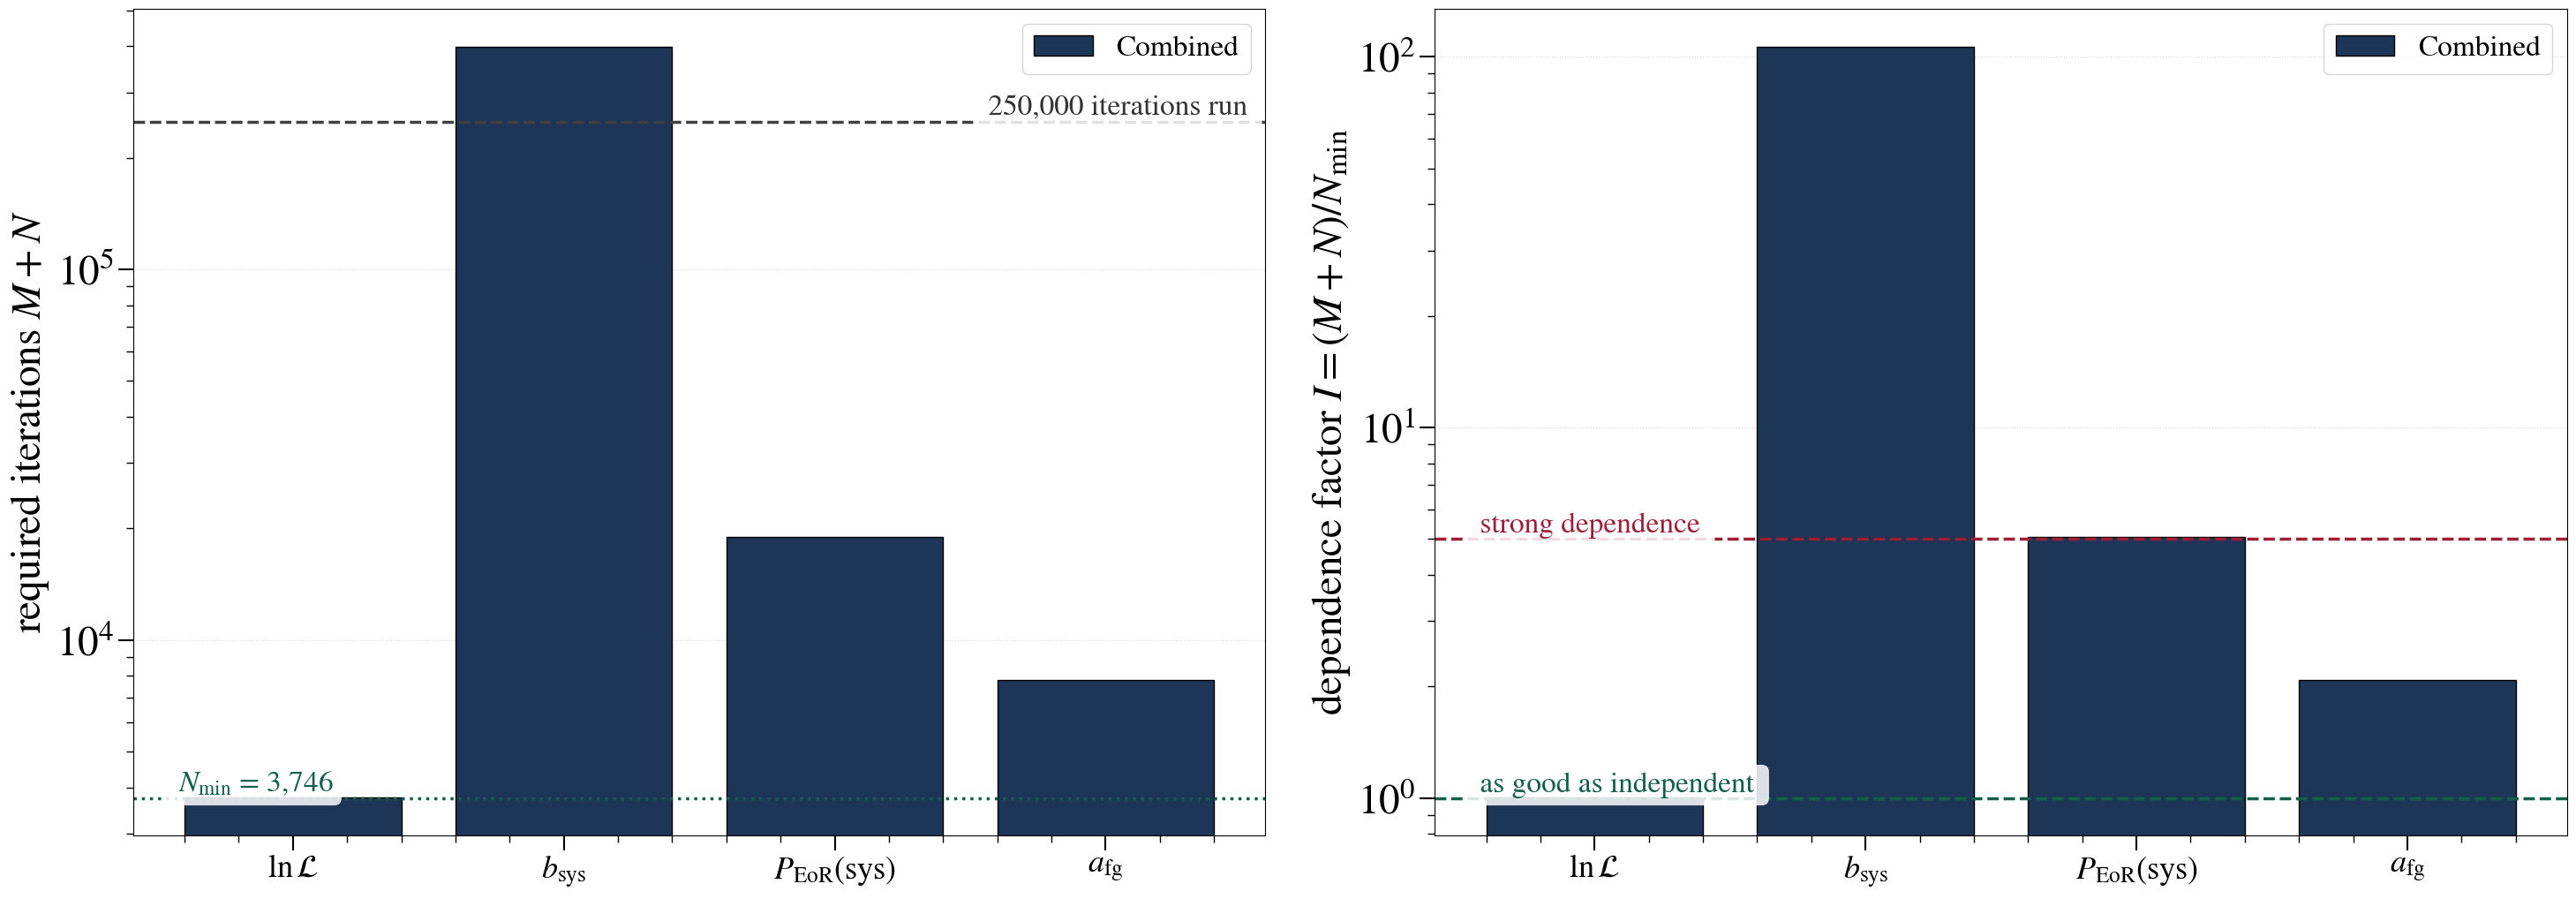

In [79]:
# ── Figure C4: Raftery-Lewis requirement against the run actually done ──────
_blocks = [st['group'] for st in rl_stats[0]]
_labels = [conv_group_tex[g] for g in _blocks]
_x = np.arange(len(_blocks), dtype=float)
_w = 0.8 / Ncases

fig, axs = plt.subplots(1, 2, figsize=(30, 11))

for i in range(Ncases):
    off = (i - (Ncases - 1) / 2.) * _w
    req = [_nanagg(np.nanmax, st['total']) for st in rl_stats[i]]
    dep = [_nanagg(np.nanmax, st['I'])     for st in rl_stats[i]]
    axs[0].bar(_x + off, req, _w, color=case_colors[i], edgecolor='k',
               label=case_labels[i])
    axs[1].bar(_x + off, dep, _w, color=case_colors[i], edgecolor='k',
               label=case_labels[i])

# One dashed line per distinct run length: bars above it were not satisfied.
for n_used in sorted(set(Niter_all)):
    axs[0].axhline(n_used, color='0.25', ls='--', lw=2.5)
    axs[0].text(len(_blocks) - 0.45, n_used, f' {n_used:,} iterations run ',
                ha='right', va='bottom', fontsize=24, color='0.2',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))
axs[0].axhline(RL_NMIN, color=tbl.C_GOOD_TXT, ls=':', lw=2.5)
axs[0].text(-0.45, RL_NMIN, f' $N_\\mathrm{{min}}$ = {RL_NMIN:,} ', ha='left',
            va='bottom', fontsize=24, color=tbl.C_GOOD_TXT,
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))
axs[0].set_ylabel('required iterations $M + N$')
axs[0].set_yscale('log')

for y, lab, colr in ((1., 'as good as independent', tbl.C_GOOD_TXT),
                     (5., 'strong dependence', tbl.C_BAD_TXT)):
    axs[1].axhline(y, color=colr, ls='--', lw=2.5)
    axs[1].text(-0.45, y, f' {lab} ', ha='left', va='bottom', fontsize=24,
                color=colr,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))
axs[1].set_ylabel(r'dependence factor $I = (M+N)/N_\mathrm{min}$')
axs[1].set_yscale('log')

for ax in axs:
    ax.set_xticks(_x)
    ax.set_xticklabels(_labels, fontsize=26)
    ax.grid(axis='y', ls=':', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(fontsize=24, ncol=min(Ncases, 4))
    ax.minorticks_on()
    ax.tick_params(which='major', direction='out', length=12, width=1.5)
    ax.tick_params(which='minor', direction='out', length=6, width=1.0)

plt.tight_layout()
save_fig(f'raftery_lewis{fig_suffix}.pdf')
print('Raftery-Lewis required run length, (C4)')

---
# Export the tables

Every table shown above is also written to `table_dir` in four formats, so that
the results can be shared without re-running anything:

| file | paste it into |
|------|---------------|
| `*.md` | GitHub, Slack, Notion, an email |
| `*.tex` | the paper (a ready-made `tabular`) |
| `*.csv` | a spreadsheet |
| `*.html` | Google Docs, Word, an HTML email — keeps the colours |

The same Markdown and LaTeX source is available directly under each table, from
the "Markdown / LaTeX source" fold-out.

In [80]:
# ── Export every table that was built above ─────────────────────────────────
# `tbl.TABLES` collects each table as it is created, keyed by its `name=`.
print('Tables built in this notebook:')
for _name, _t in tbl.TABLES.items():
    print(f'  {_name:<34s} {_t.title}')

if SAVE_TABLES:
    print()
    tbl.save_tables(table_dir)
else:
    print('\n(SAVE_TABLES=False, nothing written)')

Tables built in this notebook:
  table1_ess_bsys                    Table 1 — sampling efficiency of the systematic amplitudes b_sys
  tableC1_convergence_blocks         Table C1 — convergence diagnostics per parameter block
  tableC2_convergence_summary        Table C2 — convergence summary, one row per case
  tableC3_convergence_ranking        Table C3 — ranking of the cases (1 = best)
  tableC4_slowest_scalar             Table C4 — the bottleneck parameter of each case
  tableC5_bias_vs_mcse               Table C5 — accuracy of the recovered systematic amplitudes
  tableC6_raftery_lewis_blocks       Table C6 — Raftery-Lewis required run length, per parameter block
  tableC7_raftery_lewis_worst        Table C7 — the parameter that sets each case’s required run length

(SAVE_TABLES=False, nothing written)


# Time elapsed

In [81]:
elapsed = time.time() - _notebook_start
print(f'Notebook finished in {elapsed / 60.:.1f} min ({elapsed:.0f} s)')

Notebook finished in 0.2 min (11 s)
